# Log analysis notebook

In [ ]:
PIPELINE_TEST = False

if PIPELINE_TEST == True:
  path = "/content/drive/path/to/your/test/data" #This can be the results of your smoke tests, for example
else:
  path = "/content/drive/path/to/your/live/data"

path

'/content/drive/MyDrive/College - Everything else/MSc. Cybersecurity/Final-case-study/data'

### Initialize Taguchi Matrix (for success calculation)

In [2]:
import pandas as pd

def generate_dynamic_taguchi_l16():
    # Define factor levels based on your experimental parameters
    cpu_levels = [8, 6, 4, 2]
    mem_levels = [32, 24, 16, 8]
    bw_levels = [20, 15, 10, 5]

    records = []

    # Generate all 16 runs programmatically using bitwise XOR (GF(2^2) logic)
    for i in range(16):
        col_A = i // 4         # First base column (CPU)
        col_C = i % 4          # Second base column (Bandwidth)
        col_B = col_A ^ col_C  # Orthogonal third column (Memory) via XOR

        # Map structural indices to physical system constraints
        cpu = cpu_levels[col_A]
        mem = mem_levels[col_B]
        bw = bw_levels[col_C]

        records.append({
            "Run_ID": f"L16_{i+1:02d}",
            "CPU_Cores": cpu,
            "Memory_GB": mem,
            "Bandwidth_MBps": bw
        })

    df = pd.DataFrame(records)

    # Generate the formatted Bash array output string
    bash_array = "EXPERIMENTS=(\n"
    for _, row in df.iterrows():
        cpu = row['CPU_Cores']
        mem = row['Memory_GB']
        bw = row['Bandwidth_MBps']
        run = row['Run_ID']

        bash_array += f'  "{run}:{cpu}:{mem}:{bw}:experiment-configs/L16-testing:L16-finding-{cpu}c.yaml:L16-fixing-{cpu}c.yaml"\n'
    bash_array += ")"

    return df, bash_array

if __name__ == "__main__":
    matrix_df, bash_output = generate_dynamic_taguchi_l16()

    print("--- DETAILED EXPERIMENTAL MATRIX ---")
    print(matrix_df.to_string(index=False))

    print("\n--- GENERATED BASH ARRAY FOR EXECUTION ---")
    print(bash_output)

--- DETAILED EXPERIMENTAL MATRIX ---
Run_ID  CPU_Cores  Memory_GB  Bandwidth_MBps
L16_01          8         32              20
L16_02          8         24              15
L16_03          8         16              10
L16_04          8          8               5
L16_05          6         24              20
L16_06          6         32              15
L16_07          6          8              10
L16_08          6         16               5
L16_09          4         16              20
L16_10          4          8              15
L16_11          4         32              10
L16_12          4         24               5
L16_13          2          8              20
L16_14          2         16              15
L16_15          2         24              10
L16_16          2         32               5

--- GENERATED BASH ARRAY FOR EXECUTION ---
EXPERIMENTS=(
  "L16_01:8:32:20:experiment-configs/L16-testing:L16-finding-8c.yaml:L16-fixing-8c.yaml"
  "L16_02:8:24:15:experiment-configs/L16-testing:L1

## Set up Lakehouse

### Import logs and convert to dict

In [3]:
import os
import duckdb
import pandas as pd

# 1. Initialize Engine and Paths
con = duckdb.connect()
source_vault = path  # Ensure 'path' is defined in your environment
bronze_dir = '/content/lakehouse_archive/bronze'
os.makedirs(bronze_dir, exist_ok=True)

# 2. Build the Manifest Data
mapping_data = []

print(f"Scanning {source_vault} to generate the Metadata Catalog...")

for root, dirs, files in os.walk(source_vault):
    # We look for any valid target files to identify an active experiment folder
    if any(f.endswith('.txt') or f.endswith('.log') for f in files):

        # THE FIX: Calculate the relative path from the vault, and grab the first folder
        relative_path = os.path.relpath(root, source_vault)
        folder_key = relative_path.split(os.sep)[0]

        # Catch edge cases where the files are in the root directory (represented as '.')
        if folder_key == '.':
            folder_key = "base_logs"

        safe_filename = folder_key.replace("/", "_").replace(" ", "_") + ".parquet"

        mapping_data.append({
            'experiment_key': folder_key,
            # Store the root folder path for the experiment, not the nested path
            'source_folder_path': os.path.join(source_vault, folder_key),
            'expected_parquet_file': safe_filename
        })

# 3. Deduplicate and Convert to DataFrame
# We drop duplicates so each root experiment is only registered exactly once
mapping_df = pd.DataFrame(mapping_data).drop_duplicates(subset=['experiment_key'])

# 4. Mint the key.parquet Manifest
con.execute("CREATE OR REPLACE TABLE catalog AS SELECT * FROM mapping_df")
key_file_path = os.path.join(bronze_dir, 'key.parquet')
con.execute(f"COPY catalog TO '{key_file_path}' (FORMAT PARQUET)")

print(f"Found {len(mapping_df)} active fuzzer experiments.")
print(f"Successfully minted {key_file_path} as the pipeline manifest.")

# 5. Verify the Output
print("\nManifest Preview:")
display(con.execute(f"SELECT * FROM read_parquet('{key_file_path}')").df())

Scanning /content/drive/MyDrive/College - Everything else/MSc. Cybersecurity/Final-case-study/data to generate the Metadata Catalog...
Found 33 active fuzzer experiments.
Successfully minted /content/lakehouse_archive/bronze/key.parquet as the pipeline manifest.

Manifest Preview:


,experiment_key,source_folder_path,expected_parquet_file
0,base_logs,/content/drive/MyDrive/College - Everything el...,base_logs.parquet
1,sacrifice-L16_01_baseline,/content/drive/MyDrive/College - Everything el...,sacrifice-L16_01_baseline.parquet
2,sacrifice2-L16_01_baseline,/content/drive/MyDrive/College - Everything el...,sacrifice2-L16_01_baseline.parquet
3,validate-L16_03_stepdown,/content/drive/MyDrive/College - Everything el...,validate-L16_03_stepdown.parquet
4,validate-L16_04_starved,/content/drive/MyDrive/College - Everything el...,validate-L16_04_starved.parquet
5,validate-L16_05_stepdown,/content/drive/MyDrive/College - Everything el...,validate-L16_05_stepdown.parquet
6,validate-L16_07_starved,/content/drive/MyDrive/College - Everything el...,validate-L16_07_starved.parquet
7,validate-L16_08_stepdown,/content/drive/MyDrive/College - Everything el...,validate-L16_08_stepdown.parquet
8,validate-L16_09_stepdown,/content/drive/MyDrive/College - Everything el...,validate-L16_09_stepdown.parquet
9,validate-L16_10_starved,/content/drive/MyDrive/College - Everything el...,validate-L16_10_starved.parquet


### Generate completed runplan (total attempts)

NB p = total failures / total attempts, as per Saeed Maghsoodloo (see page 78 of that textbook)

In [4]:
import os
import re
import duckdb
import pandas as pd

# 1. Initialize Engine and Paths
con = duckdb.connect()
source_vault = path # Adjust if needed
bronze_dir = '/content/lakehouse_archive/bronze'
os.makedirs(bronze_dir, exist_ok=True)

# 2. Build the Raw Manifest Data
mapping_data = []

print(f"Scanning {source_vault} to generate the iterative tracking catalog...")

for root, dirs, files in os.walk(source_vault):
    if any(f.endswith('.txt') or f.endswith('.log') for f in files):
        relative_path = os.path.relpath(root, source_vault)
        folder_key = relative_path.split(os.sep)[0]

        if folder_key == '.':
            folder_key = "base_logs"

        # We no longer generate or append the file path logic here
        mapping_data.append({
            'experiment_key': folder_key
        })

# 3. Deduplicate to get unique experiment folders
mapping_df = pd.DataFrame(mapping_data).drop_duplicates(subset=['experiment_key'])

# ==========================================
# 4. Blind Config Extraction
# ==========================================
def extract_base_config(folder_name):
    match = re.search(r'(?i)l16(?:-smoke)?_0?(\d{1,2})', folder_name)

    if match:
        return f"L16_{int(match.group(1)):02d}"
    return "Unknown_Config"

mapping_df['base_config'] = mapping_df['experiment_key'].apply(extract_base_config)

mapping_df = mapping_df[mapping_df['base_config'] != "Unknown_Config"].copy()
mapping_df = mapping_df.sort_values(by=['base_config', 'experiment_key']).reset_index(drop=True)

# ==========================================
# 5. Zero-Indexed Run Counting & Deduplication
# ==========================================
mapping_df['iteration_index'] = mapping_df.groupby('base_config').cumcount()
mapping_df['total_runs_found'] = mapping_df.groupby('base_config')['experiment_key'].transform('count')

# Reorder columns to just the metrics we care about
final_df = mapping_df[['base_config', 'iteration_index', 'total_runs_found', 'experiment_key']]

# Filter to only keep the 0th iteration, perfectly deduplicating the matrix
final_df = final_df[final_df['iteration_index'] == 0].reset_index(drop=True)

# 6. Mint the Iteration Tracking Manifest
con.execute("CREATE OR REPLACE TABLE catalog AS SELECT * FROM final_df")
key_file_path = os.path.join(bronze_dir, 'execution_counts_key.parquet')
con.execute(f"COPY catalog TO '{key_file_path}' (FORMAT PARQUET)")

print(f"Successfully processed and deduplicated down to {len(final_df)} unique base configurations.")
print(f"Minted iterative tracking manifest at: {key_file_path}\n")

# 7. Verify the Output
print("Manifest Preview:")
display(con.execute(f"SELECT * FROM read_parquet('{key_file_path}')").df())

Scanning /content/drive/MyDrive/College - Everything else/MSc. Cybersecurity/Final-case-study/data to generate the iterative tracking catalog...
Successfully processed and deduplicated down to 16 unique base configurations.
Minted iterative tracking manifest at: /content/lakehouse_archive/bronze/execution_counts_key.parquet

Manifest Preview:


,base_config,iteration_index,total_runs_found,experiment_key
0,L16_01,0,4,L16_01_baseline
1,L16_02,0,2,L16_02_stepdown
2,L16_03,0,4,L16_03_stepdown
3,L16_04,0,2,L16_04_starved
4,L16_05,0,3,L16_05_stepdown
5,L16_06,0,2,L16_06_baseline
6,L16_07,0,2,L16_07_starved
7,L16_08,0,2,L16_08_stepdown
8,L16_09,0,3,L16_09_stepdown
9,L16_10,0,2,L16_10_starved


### Set up DuckDB and helpers

In [5]:
import os
import shutil

colab_tmp = '/content/.tmp'
freed_mb = 0
killed_items = 0

print("Scanning /content/.tmp for ALL orphaned DuckDB debris...")

if os.path.exists(colab_tmp):
    for item in os.listdir(colab_tmp):
        # Broadened to catch temp_block, temp_storage, or anything else
        if 'duckdb' in item.lower():
            target = os.path.join(colab_tmp, item)

            # Calculate size accurately whether it's a file or a nested directory
            if os.path.isfile(target):
                size_mb = os.path.getsize(target) / (1024 * 1024)
            elif os.path.isdir(target):
                size_mb = 0
                for path, dirs, files in os.walk(target):
                    for f in files:
                        fp = os.path.join(path, f)
                        size_mb += os.path.getsize(fp) / (1024 * 1024)

            freed_mb += size_mb

            # The kill shot: handle both files and directories
            if os.path.isdir(target):
                shutil.rmtree(target, ignore_errors=True)
            else:
                os.remove(target)

            killed_items += 1

print(f"Vaporized {killed_items} orphaned files/directories.")
print(f"Reclaimed {freed_mb:.2f} MB ({freed_mb / 1024:.2f} GB) of storage!")

Scanning /content/.tmp for ALL orphaned DuckDB debris...
Vaporized 0 orphaned files/directories.
Reclaimed 0.00 MB (0.00 GB) of storage!


In [6]:
import duckdb
import os

# 1. Initialize a persistent connection to the Colab disk
db_path = '/content/fuzzer_telemetry.db'
con = duckdb.connect(db_path)

# 2. Lock in the safety PRAGMAs immediately on this connection
con.execute("PRAGMA memory_limit='10GB'")
con.execute("PRAGMA temp_directory='/content/duckdb_swap'")

print("DuckDB initialized.")

DuckDB initialized.


In [7]:
import duckdb
import gc
import os
import shutil

def flush_and_reconnect(active_con, db_path='/content/fuzzer_telemetry.db', swap_dir='/content/duckdb_swap'):
    """
    Force closes the DuckDB connection, flushes Python RAM, clears orphaned swap,
    recovers stranded WAL data, and returns a freshly armored engine.
    """
    print("1. Closing active DuckDB connection...")
    try:
        active_con.close()
    except Exception as e:
        print(f"   Note: Connection was already closed or invalid.")

    print("2. Forcing Python garbage collection (RAM clear)...")
    gc.collect()

    print("3. Obliterating orphaned disk swap files...")
    if os.path.exists(swap_dir):
        shutil.rmtree(swap_dir, ignore_errors=True)
    os.makedirs(swap_dir, exist_ok=True)

    print("4. Spinning up engine & checking for stranded WAL data...")
    # The moment DuckDB connects, it automatically reads the .wal file into RAM
    new_con = duckdb.connect(db_path)

    # We immediately force it to write that RAM back into the main .db file
    new_con.execute("FORCE CHECKPOINT;")
    print("WAL merged. Main database file is secure.")

    print("5. Re-arming Titanium safety limits...")
    new_con.execute("PRAGMA memory_limit='8GB'")
    new_con.execute(f"PRAGMA temp_directory='{swap_dir}'")

    print("Flush and recovery complete. System is ready.")
    return new_con

# ==========================================
# HOW TO USE IT
# ==========================================
con = flush_and_reconnect(con)

1. Closing active DuckDB connection...
2. Forcing Python garbage collection (RAM clear)...
3. Obliterating orphaned disk swap files...
4. Spinning up engine & checking for stranded WAL data...
WAL merged. Main database file is secure.
5. Re-arming Titanium safety limits...
Flush and recovery complete. System is ready.


### Convert logs into Parquet (partitioned - bronze)

In [8]:
import os
import re
import duckdb
import pandas as pd

con = duckdb.connect()

# ==========================================
# 1. READ THE MANIFEST
# ==========================================
print("Loading Metadata Manifest for Bronze Ingestion...")
bronze_dir = '/content/lakehouse_archive/bronze'
key_file_path = os.path.join(bronze_dir, 'key.parquet')

# Fetch the raw catalog (This assumes key.parquet still has the source_folder_path!)
catalog_records = con.execute(f"SELECT experiment_key, source_folder_path, expected_parquet_file FROM read_parquet('{key_file_path}')").fetchall()

print(f"Loaded {len(catalog_records)} fuzzer experiments. Rebuilding Bronze layer...")
con.execute("PRAGMA memory_limit='8GB'")

total_files_ingested = 0
failure_tracker = {}

# The Blind Regex Extractor
def extract_base_config(folder_name):
    match = re.search(r'(?i)l16(?:-smoke)?_0?(\d{1,2})', folder_name)
    if match:
        return f"L16_{int(match.group(1)):02d}"
    return "Unknown_Config"

# ==========================================
# 2. BUILD BRONZE (DRIVEN BY MANIFEST)
# ==========================================
for exp_key, source_folder, parquet_filename in catalog_records:
    target_parquet = os.path.join(bronze_dir, parquet_filename)

    # Identify the base Taguchi configuration
    base_config = extract_base_config(exp_key)
    if base_config not in failure_tracker and base_config != "Unknown_Config":
        failure_tracker[base_config] = 0

    # 1. Gather ALL files for this specific top-level experiment recursively
    valid_files = []
    for root, dirs, files in os.walk(source_folder):
        for file in files:
            if file.endswith('.txt') or file.endswith('.log'):
                file_path = os.path.join(root, file)
                if os.path.getsize(file_path) > 0:
                    valid_files.append(file_path)

    total_files_ingested += len(valid_files)

    if not valid_files:
        print(f"Skipping {exp_key} - no valid logs found.")
        continue

    # ---> THE DIAGNOSTIC LOGIC: Flag as failed if exactly 1 log file was produced <---
    if len(valid_files) == 1 and base_config != "Unknown_Config":
        failure_tracker[base_config] += 1

    print(f"Packing {len(valid_files)} files into {parquet_filename}...")

    # 2. Stream directly from Text to Parquet
    query = f"""
        COPY (
            SELECT
                column0 AS raw_line,
                filename AS full_path,
                '{exp_key}' AS experiment_name
            FROM read_csv(
                ?,
                header=false,
                sep='\\x00',
                quote='',
                escape='',
                filename=true,
                union_by_name=true,
                auto_detect=false,
                columns={{'column0': 'VARCHAR'}},
                ignore_errors=true,
                max_line_size=20000000,
                null_padding=true,
                strict_mode=false
            )
        ) TO '{target_parquet}' (FORMAT PARQUET, COMPRESSION 'snappy');
    """
    con.execute(query, [valid_files])

print("==========================================")
print("Bronze Lakehouse sync complete.")

# ==========================================
# 3. UPDATE THE EXECUTION COUNTS TABLE
# ==========================================
execution_key_path = os.path.join(bronze_dir, 'execution_counts_key.parquet')

if os.path.exists(execution_key_path):
    print("Enriching Execution Counts manifest with failure metrics...")

    # Load the deduplicated analytical table
    exec_df = con.execute(f"SELECT * FROM read_parquet('{execution_key_path}')").df()

    # Convert the failure dictionary into a DataFrame
    failure_df = pd.DataFrame(list(failure_tracker.items()), columns=['base_config', 'failed_runs'])

    # Left join to append the 'failed_runs' column to your existing matrix
    merged_df = pd.merge(exec_df, failure_df, on='base_config', how='left')

    # Fill any null values (configurations with zero failures) with 0 and cast to integer
    merged_df['failed_runs'] = merged_df['failed_runs'].fillna(0).astype(int)

    # Overwrite the parquet file with the newly enriched table
    con.execute(f"COPY merged_df TO '{execution_key_path}' (FORMAT PARQUET)")

    print("Updated Tracking Manifest Preview:")
    display(merged_df)
else:
    print(f"Notice: {execution_key_path} not found. Skipping failure tracking injection.")
print("==========================================")

# ==========================================
# 4. VERIFICATION
# ==========================================
# NOTE: Updated to strictly exclude 'key' to protect against the new execution_counts_key file crashing the schema
data_parquets = [os.path.join(bronze_dir, f) for f in os.listdir(bronze_dir) if f.endswith('.parquet') and 'key' not in f]

con.execute(f"""
    CREATE OR REPLACE VIEW raw_logs AS
    SELECT * FROM read_parquet({data_parquets})
""")

total_rows = con.execute("SELECT count(*) FROM raw_logs").fetchone()[0]
print(f"Successfully mounted {total_rows} rows across {total_files_ingested} files.")
print("==========================================")

Loading Metadata Manifest for Bronze Ingestion...
Loaded 33 fuzzer experiments. Rebuilding Bronze layer...
Skipping base_logs - no valid logs found.
Packing 58 files into sacrifice-L16_01_baseline.parquet...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Packing 1 files into sacrifice2-L16_01_baseline.parquet...
Packing 64 files into validate-L16_03_stepdown.parquet...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Packing 24 files into validate-L16_04_starved.parquet...
Packing 48 files into validate-L16_05_stepdown.parquet...


...

Packing 64 files into throwaway-L16_16_baseline.parquet...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Packing 1 files into validation-test.parquet...
Bronze Lakehouse sync complete.
Enriching Execution Counts manifest with failure metrics...
Updated Tracking Manifest Preview:


,base_config,iteration_index,total_runs_found,experiment_key,failed_runs
0,L16_01,0,4,L16_01_baseline,2
1,L16_02,0,2,L16_02_stepdown,1
2,L16_03,0,4,L16_03_stepdown,2
3,L16_04,0,2,L16_04_starved,0
4,L16_05,0,3,L16_05_stepdown,0
5,L16_06,0,2,L16_06_baseline,1
6,L16_07,0,2,L16_07_starved,0
7,L16_08,0,2,L16_08_stepdown,0
8,L16_09,0,3,L16_09_stepdown,0
9,L16_10,0,2,L16_10_starved,0


Successfully mounted 380755967 rows across 1065 files.


## Load Lakehouse into DuckDB

In [9]:
# 1. Create a View pointing to all Parquet files in the directory
# The *.parquet wildcard targets every experiment file at once
con.execute(f"""
    CREATE OR REPLACE VIEW raw_logs AS
    SELECT * FROM read_parquet('{bronze_dir}/*.parquet')
""")

# 2. Verify the mount
total_rows = con.execute("SELECT count(*) FROM raw_logs").fetchone()[0]
print(f"Successfully mounted {total_rows} rows across all Parquet files.")

Successfully mounted 380756016 rows across all Parquet files.


### Initial cleanup and deduplication (bronze to silver)

In [10]:
import os
import duckdb

con = duckdb.connect()

# ==========================================
# 1. READ THE MANIFEST (KEY TABLE)
# ==========================================
print("Loading Metadata Manifest...")
bronze_dir = '/content/lakehouse_archive/bronze'
silver_dir = '/content/lakehouse_archive/silver'

os.makedirs(silver_dir, exist_ok=True)
key_file_path = os.path.join(bronze_dir, 'key.parquet')

# Fetch the catalog
catalog_records = con.execute(f"SELECT experiment_key, expected_parquet_file FROM read_parquet('{key_file_path}')").fetchall()
print(f"Loaded {len(catalog_records)} registered experiments from manifest.")

# ==========================================
# 2. SET MEMORY SAFEGUARDS
# ==========================================
print("\nInitiating manifest-driven Silver extraction and deduplication...")

# Allow out-of-core sorting and enable SSD swap spilling
con.execute("SET preserve_insertion_order = false;")
con.execute("PRAGMA memory_limit='6GB'")
con.execute("PRAGMA temp_directory='/content/duckdb_swap'")

# ==========================================
# 3. MANIFEST-DRIVEN SILVER ETL & DEDUPLICATION
# ==========================================
unified_query = r"""
COPY (
    WITH base_filter AS (
        -- Explicitly CAST everything to string to prevent chunk type panics during SSD spill
        SELECT
            CAST(raw_line AS VARCHAR) AS raw_line,
            CAST(full_path AS VARCHAR) AS full_path,
            CAST(experiment_name AS VARCHAR) AS experiment_name
        FROM read_parquet(?)
        WHERE full_path LIKE '%.txt'
           OR full_path LIKE '%.log'
    ),
    deduplicated_logs AS (
        -- Explicit GROUP BY is much safer for out-of-core SSD processing
        SELECT
            raw_line,
            full_path,
            experiment_name
        FROM base_filter
        GROUP BY
            raw_line,
            full_path,
            experiment_name
    )
    SELECT
        raw_line,
        full_path,
        experiment_name,
        -- Run the Regex extraction AFTER deduplication to save CPU cycles
        regexp_extract(raw_line, '\|\s*([A-Z]+)\s*\|', 1) AS severity
    FROM deduplicated_logs
) TO 'TARGET_PLACEHOLDER' (FORMAT PARQUET, COMPRESSION 'snappy');
"""

# THE MISSING PIECE: Execute the query for every file in the catalog
for exp_key, parquet_filename in catalog_records:
    bronze_path = os.path.join(bronze_dir, parquet_filename)
    target_file = os.path.join(silver_dir, parquet_filename)

    if os.path.exists(bronze_path):
        print(f"Routing, deduplicating, and parsing {exp_key} -> {parquet_filename}")
        formatted_query = unified_query.replace('TARGET_PLACEHOLDER', target_file)
        con.execute(formatted_query, [bronze_path])

# ==========================================
# 4. VERIFICATION
# ==========================================
silver_count = con.execute(f"SELECT count(*) FROM read_parquet('{silver_dir}/*.parquet')").fetchone()[0]
print("==========================================")
print("Silver Lakehouse construction complete.")
print(f"Successfully preserved {silver_count} rows.")
print("==========================================")

Loading Metadata Manifest...
Loaded 33 registered experiments from manifest.

Initiating manifest-driven Silver extraction and deduplication...
Routing, deduplicating, and parsing sacrifice-L16_01_baseline -> sacrifice-L16_01_baseline.parquet


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Routing, deduplicating, and parsing sacrifice2-L16_01_baseline -> sacrifice2-L16_01_baseline.parquet
Routing, deduplicating, and parsing validate-L16_03_stepdown -> validate-L16_03_stepdown.parquet


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Routing, deduplicating, and parsing validate-L16_04_starved -> validate-L16_04_starved.parquet
Routing, deduplicating, and parsing validate-L16_05_stepdown -> validate-L16_05_stepdown.parquet


...

Routing, deduplicating, and parsing throwaway-L16_09_stepdown -> throwaway-L16_09_stepdown.parquet


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Routing, deduplicating, and parsing throwaway-L16_16_baseline -> throwaway-L16_16_baseline.parquet


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Routing, deduplicating, and parsing validation-test -> validation-test.parquet
Silver Lakehouse construction complete.
Successfully preserved 196574810 rows.


### Fast severity count

In [11]:
target_lakehouse_path = '/content/lakehouse_archive/silver/*.parquet'

fast_silver_query = rf"""
SELECT
    severity,
    count(*) AS occurrences
FROM read_parquet('{target_lakehouse_path}')
WHERE severity IS NOT NULL
  AND severity != ''
GROUP BY severity
ORDER BY occurrences DESC;
"""

display(con.execute(fast_silver_query).df())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,severity,occurrences
0,INFO,189554118
1,WARNING,25591
2,ERROR,20859
3,DEBUG,215


### Calculate failure scores (p-scores)

In [12]:
import os
import duckdb

con = duckdb.connect()

# Define paths
bronze_dir = '/content/lakehouse_archive/bronze'
gold_dir = '/content/lakehouse_archive/gold'
os.makedirs(gold_dir, exist_ok=True)

execution_key_path = os.path.join(bronze_dir, 'execution_counts_key.parquet')
gold_failure_path = os.path.join(gold_dir, 'configuration_reliability.parquet')

print("Calculating specification failure rates...")

# Calculate the metrics natively in DuckDB and stream straight to Gold
query = f"""
    COPY (
        SELECT
            base_config,
            total_runs_found,
            failed_runs,
            -- Calculate raw float for plotting/analytics
            (CAST(failed_runs AS DOUBLE) / CAST(total_runs_found AS DOUBLE)) AS failure_rate,
            -- Calculate a clean percentage string for easy reading
            ROUND((CAST(failed_runs AS DOUBLE) / CAST(total_runs_found AS DOUBLE)) * 100, 2) AS failure_percentage
        FROM read_parquet('{execution_key_path}')
        ORDER BY base_config ASC
    ) TO '{gold_failure_path}' (FORMAT PARQUET, COMPRESSION 'snappy');
"""

con.execute(query)

print(f"Successfully minted Gold reliability metrics at: {gold_failure_path}\n")

# Pull it back into Pandas to view the final Gold table
print("--- Failure Rates per configuration ---")
df_failure_rates = con.execute(f"SELECT * FROM read_parquet('{gold_failure_path}')").df()
display(df_failure_rates)

Calculating specification failure rates...
Successfully minted Gold reliability metrics at: /content/lakehouse_archive/gold/configuration_reliability.parquet

--- Failure Rates per configuration ---


,base_config,total_runs_found,failed_runs,failure_rate,failure_percentage
0,L16_01,4,2,0.5,50.0
1,L16_02,2,1,0.5,50.0
2,L16_03,4,2,0.5,50.0
3,L16_04,2,0,0.0,0.0
4,L16_05,3,0,0.0,0.0
5,L16_06,2,1,0.5,50.0
6,L16_07,2,0,0.0,0.0
7,L16_08,2,0,0.0,0.0
8,L16_09,3,0,0.0,0.0
9,L16_10,2,0,0.0,0.0


### Generate signal to noise ratio - Static

Higher is better

In [13]:
import os
import duckdb

con = duckdb.connect()

# Define paths
bronze_dir = '/content/lakehouse_archive/bronze'
gold_dir = '/content/lakehouse_archive/gold'
os.makedirs(gold_dir, exist_ok=True)

execution_key_path = os.path.join(bronze_dir, 'execution_counts_key.parquet')
gold_failure_path = os.path.join(gold_dir, 'configuration_reliability.parquet')

print("Calculating Taguchi Signal-to-Noise (dB) metrics...")

# Calculate the metrics natively in DuckDB and stream straight to Gold
query = f"""
    COPY (
        WITH base_metrics AS (
            SELECT
                base_config,
                total_runs_found,
                failed_runs,
                -- Calculate raw fraction 'p' for the formula
                (CAST(failed_runs AS DOUBLE) / CAST(total_runs_found AS DOUBLE)) AS raw_p,
                -- Calculate a clean percentage string for easy reading
                ROUND((CAST(failed_runs AS DOUBLE) / CAST(total_runs_found AS DOUBLE)) * 100, 2) AS failure_percentage
            FROM read_parquet('{execution_key_path}')
        ),
        clamped_metrics AS (
            SELECT
                *,
                -- Apply an epsilon clamp so p never hits absolute 0.0 or 1.0
                GREATEST(0.001, LEAST(0.999, raw_p)) AS safe_p
            FROM base_metrics
        )
        SELECT
            base_config,
            total_runs_found,
            failed_runs,
            raw_p AS failure_rate,
            failure_percentage,
            -- Maghsoodloo's Signal-to-Noise Ratio for attribute data using safe_p
            10 * log10((1.0 - safe_p) / safe_p) AS signal_to_noise_db
        FROM clamped_metrics
        ORDER BY base_config ASC
    ) TO '{gold_failure_path}' (FORMAT PARQUET, COMPRESSION 'snappy');
"""

con.execute(query)

print(f"Successfully minted Gold reliability metrics at: {gold_failure_path}\n")

# Pull it back into Pandas to view the final Gold table
print("--- Taguchi Matrix: Signal-to-Noise Ratios ---")
df_failure_rates = con.execute(f"SELECT * FROM read_parquet('{gold_failure_path}')").df()
display(df_failure_rates)

Calculating Taguchi Signal-to-Noise (dB) metrics...
Successfully minted Gold reliability metrics at: /content/lakehouse_archive/gold/configuration_reliability.parquet

--- Taguchi Matrix: Signal-to-Noise Ratios ---


,base_config,total_runs_found,failed_runs,failure_rate,failure_percentage,signal_to_noise_db
0,L16_01,4,2,0.5,50.0,0.000000
1,L16_02,2,1,0.5,50.0,0.000000
2,L16_03,4,2,0.5,50.0,0.000000
3,L16_04,2,0,0.0,0.0,29.995655
4,L16_05,3,0,0.0,0.0,29.995655
5,L16_06,2,1,0.5,50.0,0.000000
6,L16_07,2,0,0.0,0.0,29.995655
7,L16_08,2,0,0.0,0.0,29.995655
8,L16_09,3,0,0.0,0.0,29.995655
9,L16_10,2,0,0.0,0.0,29.995655


### Generate Signal to Noise ratio - Rolling

In [14]:
import os
import duckdb

con = duckdb.connect()

silver_dir = '/content/lakehouse_archive/silver'
silver_lakehouse_path = f"{silver_dir}/*.parquet"

gold_dir = '/content/lakehouse_archive/gold'
os.makedirs(gold_dir, exist_ok=True)
gold_rolling_path = os.path.join(gold_dir, 'rolling_reliability.parquet')

print("Extracting deduplicated timestamps and generating Gold Rolling SNR metrics...")

con.execute("SET preserve_insertion_order = false;")
con.execute("PRAGMA memory_limit='6GB'")
con.execute("PRAGMA temp_directory='/content/duckdb_swap'")

# Merged Query: Hash Aggregation + SNR Math + Final Sort Fix
query = r"""
    COPY (
        WITH extracted_logs AS (
            SELECT
                experiment_name,
                severity,
                TRY_CAST(NULLIF(regexp_extract(raw_line, '^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})', 1), '') AS TIMESTAMP) AS timestamp,
                -- We extract the message to use as a tie-breaker for identical timestamps
                trim(regexp_extract(raw_line, '\|\s*[A-Z]+\s*\|(.*)', 1)) AS message
            FROM read_parquet('TARGET_PLACEHOLDER')
        ),
        deduplicated_events AS (
            SELECT experiment_name, timestamp, severity, message
            FROM extracted_logs
            WHERE timestamp IS NOT NULL
            GROUP BY experiment_name, timestamp, severity, message
        ),
        -- Generate a strictly increasing, un-tieable ID for every single row
        sequenced_events AS (
            SELECT
                *,
                ROW_NUMBER() OVER (PARTITION BY experiment_name ORDER BY timestamp ASC, message ASC) as event_id
            FROM deduplicated_events
        ),
        rolling_metrics AS (
            SELECT
                experiment_name,
                event_id, -- ADDED: Propagate event_id down the pipeline
                timestamp,
                -- Now we order the window by our bulletproof event_id
                COUNT(*) OVER w AS rolling_total_runs,
                SUM(CASE WHEN severity IN ('ERROR', 'FATAL') THEN 1 ELSE 0 END) OVER w AS rolling_failed_runs
            FROM sequenced_events
            WINDOW w AS (
                PARTITION BY experiment_name
                ORDER BY event_id ASC
                ROWS BETWEEN 49 PRECEDING AND CURRENT ROW
            )
        ),
        base_calculations AS (
            SELECT
                experiment_name,
                event_id, -- ADDED: Propagate event_id
                timestamp,
                rolling_total_runs,
                rolling_failed_runs,
                (CAST(rolling_failed_runs AS DOUBLE) / CAST(rolling_total_runs AS DOUBLE)) AS raw_p
            FROM rolling_metrics
            WHERE rolling_total_runs > 9
        ),
        clamped_metrics AS (
            SELECT
                *,
                GREATEST(0.001, LEAST(0.999, raw_p)) AS safe_p
            FROM base_calculations
        )
        SELECT
            experiment_name,
            timestamp,
            rolling_total_runs,
            rolling_failed_runs,
            ROUND(raw_p * 100, 2) AS rolling_failure_percentage,
            10 * log10((1.0 - safe_p) / safe_p) AS rolling_signal_to_noise_db
        FROM clamped_metrics
        -- THE FINAL FIX: Sort the physical export by the un-tieable event_id
        ORDER BY experiment_name ASC, event_id ASC
    ) TO 'GOLD_PLACEHOLDER' (FORMAT PARQUET, COMPRESSION 'snappy');
"""

# Safely inject paths
formatted_query = query.replace('TARGET_PLACEHOLDER', silver_lakehouse_path).replace('GOLD_PLACEHOLDER', gold_rolling_path)

con.execute(formatted_query)
print(f"Successfully minted Gold rolling metrics at: {gold_rolling_path}\n")

# Pull a sample back into Pandas
print("--- Time-Series: Rolling Signal-to-Noise Ratios ---")
df_rolling = con.execute(f"SELECT * FROM read_parquet('{gold_rolling_path}') LIMIT 5000").df()
display(df_rolling)

Extracting deduplicated timestamps and generating Gold Rolling SNR metrics...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Successfully minted Gold rolling metrics at: /content/lakehouse_archive/gold/rolling_reliability.parquet

--- Time-Series: Rolling Signal-to-Noise Ratios ---


,experiment_name,timestamp,rolling_total_runs,rolling_failed_runs,rolling_failure_percentage,rolling_signal_to_noise_db
0,L16_03_stepdown,2026-06-27 21:05:39,10,0.0,0.0,29.995655
1,L16_03_stepdown,2026-06-27 21:05:39,11,0.0,0.0,29.995655
2,L16_03_stepdown,2026-06-27 21:05:39,12,0.0,0.0,29.995655
3,L16_03_stepdown,2026-06-27 21:05:39,13,0.0,0.0,29.995655
4,L16_03_stepdown,2026-06-27 21:05:39,14,0.0,0.0,29.995655
...,...,...,...,...,...,...
4995,L16_03_stepdown,2026-06-27 21:22:15,50,0.0,0.0,29.995655
4996,L16_03_stepdown,2026-06-27 21:22:15,50,0.0,0.0,29.995655
4997,L16_03_stepdown,2026-06-27 21:22:15,50,0.0,0.0,29.995655
4998,L16_03_stepdown,2026-06-27 21:22:15,50,0.0,0.0,29.995655


## Extract Key Metrics
We can create a structured view of the logs by parsing the timestamp and messages directly in SQL.

In [15]:
import os
import duckdb

con = duckdb.connect()
silver_lakehouse_path = '/content/lakehouse_archive/silver/*.parquet'

print("Extracting metrics from Silver Lakehouse to physical disk table...")

print("Setting safety limits and mapping disk swap...")
con.execute("SET preserve_insertion_order = false;")
con.execute("PRAGMA memory_limit='6GB'")
con.execute("PRAGMA temp_directory='/content/duckdb_swap'")

# Use a raw string (r"") and a placeholder to protect the regex curly braces {4}
metrics_query = r"""
CREATE OR REPLACE TABLE parsed_metrics AS
WITH pre_filtered AS (
    SELECT
        raw_line,
        full_path,
        experiment_name,
        severity
    FROM read_parquet('TARGET_PLACEHOLDER')
    -- THE UPGRADE: We use our native Silver column instead of a slow substring search
    WHERE severity = 'INFO'
      AND (raw_line LIKE '%Workers connected%' OR raw_line LIKE '%Jobs complete%')
),
safe_extracted AS (
    SELECT
        TRY_CAST(NULLIF(regexp_extract(raw_line, '^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})', 1), '') AS TIMESTAMP) as timestamp,
        severity,
        -- Added trim() to ensure clean message extraction
        trim(regexp_extract(raw_line, '\|\s*[A-Z]+\s*\|(.*)', 1)) as message,
        full_path as source_file,
        experiment_name
    FROM pre_filtered
),
filtered_metrics AS (
    SELECT *
    FROM safe_extracted
    WHERE timestamp IS NOT NULL
)
-- THE UPGRADE: Vectorized Hash Aggregation
SELECT
    timestamp,
    severity,
    message,
    experiment_name,
    -- Grab the first file reference and drop duplicates instantly
    ANY_VALUE(source_file) AS source_file
FROM filtered_metrics
GROUP BY
    timestamp,
    severity,
    message,
    experiment_name;
"""

# Inject the target path safely
formatted_metrics_query = metrics_query.replace('TARGET_PLACEHOLDER', silver_lakehouse_path)

con.execute(formatted_metrics_query)

total_metrics = con.execute("SELECT COUNT(*) FROM parsed_metrics").fetchone()[0]
print(f"Extraction complete! Found {total_metrics} deduplicated orchestrator loops.")

# 1. Setup the Gold Directory path
gold_dir = '/content/lakehouse_archive/gold'
os.makedirs(gold_dir, exist_ok=True)
gold_metrics_path = os.path.join(gold_dir, 'metrics_master.parquet')

print(f"Exporting fully sorted metrics to the Gold layer...")

# 2. Dump the full, sorted table to a compressed Parquet file
export_query = f"""
COPY (
    SELECT * FROM parsed_metrics
    ORDER BY experiment_name ASC, timestamp ASC
) TO '{gold_metrics_path}' (FORMAT PARQUET, COMPRESSION 'snappy');
"""
con.execute(export_query)
con.execute("FORCE CHECKPOINT;")

print("Export complete! You can now pull a safe sample for viewing directly from Gold.")

Extracting metrics from Silver Lakehouse to physical disk table...
Setting safety limits and mapping disk swap...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Extraction complete! Found 2100640 deduplicated orchestrator loops.
Exporting fully sorted metrics to the Gold layer...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Export complete! You can now pull a safe sample for viewing directly from Gold.


In [16]:
import os
import duckdb

con = duckdb.connect()

# 1. Setup the Gold Directory path
gold_dir = '/content/lakehouse_archive/gold'
os.makedirs(gold_dir, exist_ok=True)
gold_metrics_path = os.path.join(gold_dir, 'metrics_master.parquet')

# 3. The LIMIT 5000 safety net, reading natively from the new Parquet file!
safe_pull_query = f"""
SELECT * FROM read_parquet('{gold_metrics_path}')
LIMIT 5000;
"""

duck_metrics_df = con.execute(safe_pull_query).df()
display(duck_metrics_df)

,timestamp,severity,message,experiment_name,source_file
0,2026-06-27 21:05:39,INFO,orchestrator | [utils] | Jobs complete (0 succ...,L16_03_stepdown,/content/drive/MyDrive/College - Everything el...
1,2026-06-27 21:05:39,INFO,orchestrator | [distributed] | Workers connect...,L16_03_stepdown,/content/drive/MyDrive/College - Everything el...
2,2026-06-27 21:05:42,INFO,orchestrator | [utils] | Jobs complete (0 succ...,L16_03_stepdown,/content/drive/MyDrive/College - Everything el...
3,2026-06-27 21:05:42,INFO,orchestrator | [distributed] | Workers connect...,L16_03_stepdown,/content/drive/MyDrive/College - Everything el...
4,2026-06-27 21:05:45,INFO,orchestrator | [utils] | Jobs complete (0 succ...,L16_03_stepdown,/content/drive/MyDrive/College - Everything el...
...,...,...,...,...,...
4995,2026-06-27 21:18:26,INFO,orchestrator | [utils] | Jobs complete (0 succ...,L16_07_starved,/content/drive/MyDrive/College - Everything el...
4996,2026-06-27 21:18:29,INFO,orchestrator | [utils] | Jobs complete (0 succ...,L16_07_starved,/content/drive/MyDrive/College - Everything el...
4997,2026-06-27 21:18:29,INFO,orchestrator | [distributed] | Workers connect...,L16_07_starved,/content/drive/MyDrive/College - Everything el...
4998,2026-06-27 21:18:32,INFO,orchestrator | [utils] | Jobs complete (0 succ...,L16_07_starved,/content/drive/MyDrive/College - Everything el...


### Get individual warnings, logs, debugs, et cetera.

In [17]:
import os
import duckdb

con = duckdb.connect()
silver_lakehouse_path = '/content/lakehouse_archive/silver/*.parquet'

# 1. Setup the Gold Directory
gold_dir = '/content/lakehouse_archive/gold'
os.makedirs(gold_dir, exist_ok=True)
gold_lakehouse_path = os.path.join(gold_dir, 'anomalies_master.parquet')

# ==========================================
# STEP ONE: EXTRACT & DEDUPLICATE (VECTORIZED HASH AGGREGATION)
# ==========================================
print("Extracting Gold anomalies directly to Parquet...")

print("Setting safety limits and mapping disk swap...")
con.execute("SET preserve_insertion_order = false;")
# Lock in the 6GB safeguard to keep Colab's OOM killer away
con.execute("PRAGMA memory_limit='6GB'")
con.execute("PRAGMA temp_directory='/content/duckdb_swap'")

# Note the single backslashes for \| and \s !
step_1_query = r"""
COPY (
    WITH base_extraction AS (
        SELECT
            COALESCE(
                NULLIF(regexp_extract(full_path, '([Ll]16[-_][a-zA-Z0-9_-]+)', 1), ''),
                experiment_name
            ) AS run_name,
            TRY_CAST(NULLIF(regexp_extract(raw_line, '^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})', 1), '') AS TIMESTAMP) AS timestamp,
            severity,
            trim(regexp_extract(raw_line, '\|\s*[A-Z]+\s*\|(.*)', 1)) AS message,
            split_part(full_path, '/', -1) AS source_file
        FROM read_parquet('TARGET_SILVER_PLACEHOLDER')
        WHERE regexp_matches(raw_line, '^[0-9]{4}-[0-9]{2}-[0-9]{2}')
    ),
    filtered_logs AS (
        SELECT *
        FROM base_extraction
        WHERE severity IN ('INFO', 'WARNING', 'ERROR', 'DEBUG')
          AND timestamp IS NOT NULL
    )
    -- THE UPGRADE: Vectorized Hash Aggregation
    SELECT
        run_name,
        timestamp,
        severity,
        message,
        -- Grab the first file reference we see and drop the rest instantly
        ANY_VALUE(source_file) AS source_file
    FROM filtered_logs
    GROUP BY
        run_name,
        timestamp,
        severity,
        message
) TO 'TARGET_GOLD_PLACEHOLDER' (FORMAT PARQUET, COMPRESSION 'snappy');
"""

# Safely inject both the source (Silver) and destination (Gold) paths
formatted_query = step_1_query.replace('TARGET_SILVER_PLACEHOLDER', silver_lakehouse_path)\
                              .replace('TARGET_GOLD_PLACEHOLDER', gold_lakehouse_path)

con.execute(formatted_query)

# Validate the output directly from the newly minted Gold file
unsorted_count = con.execute(f"SELECT COUNT(*) FROM read_parquet('{gold_lakehouse_path}')").fetchone()[0]
print("==========================================")
print(f"Found {unsorted_count} deduplicated anomalies secured in the Gold layer.")
print("==========================================")

Extracting Gold anomalies directly to Parquet...
Setting safety limits and mapping disk swap...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Found 5351200 deduplicated anomalies secured in the Gold layer.


In [18]:
import duckdb

con = duckdb.connect()
gold_lakehouse_path = '/content/lakehouse_archive/gold/anomalies_master.parquet'

# ==========================================
# 3. STEP TWO: THE GLOBAL SORT
# ==========================================
print("STEP 2/2: Applying final global sort to the deduplicated Gold data...")

# Set safeguards for the massive sorting operation
con.execute("SET preserve_insertion_order = false;")
con.execute("PRAGMA memory_limit='6GB'")
con.execute("PRAGMA temp_directory='/content/duckdb_swap'")

# Read directly from the newly minted Gold Parquet file
step_2_query = f"""
CREATE OR REPLACE TABLE parsed_anomalies AS
SELECT * FROM read_parquet('{gold_lakehouse_path}')
ORDER BY run_name ASC, timestamp ASC, message ASC;
"""
con.execute(step_2_query)
con.execute("FORCE CHECKPOINT;")

total_anomalies = con.execute("SELECT COUNT(*) FROM parsed_anomalies").fetchone()[0]
print(f"Extraction fully complete! Found {total_anomalies} sorted, deduplicated logs.")

# ==========================================
# 4. THE SAFE PANDAS PULL
# ==========================================
print("Pulling a safe sample for viewing...")
safe_df = con.execute("SELECT * FROM parsed_anomalies LIMIT 5000").df()
display(safe_df)

STEP 2/2: Applying final global sort to the deduplicated Gold data...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Extraction fully complete! Found 5351200 sorted, deduplicated logs.
Pulling a safe sample for viewing...


,run_name,timestamp,severity,message,source_file
0,L16_01_baseline,2026-07-11 11:25:12,INFO,[distributed] | Base worker name: crs-cleanroom,telemetry_1735.log
1,L16_01_baseline,2026-07-11 11:25:12,INFO,[distributed] | Connected to Redis successfully,telemetry_1704.log
2,L16_01_baseline,2026-07-11 11:25:12,INFO,[distributed] | Connecting to Redis at local...,telemetry_1633.log
3,L16_01_baseline,2026-07-11 11:25:12,INFO,[distributed] | Loading experiment config fr...,telemetry_1735.log
4,L16_01_baseline,2026-07-11 11:25:12,INFO,[distributed] | Spawning 3 worker processes...,telemetry_1633.log
...,...,...,...,...,...
4995,L16_01_baseline,2026-07-11 12:04:49,INFO,orchestrator | [utils] |,telemetry_1633.log
4996,L16_01_baseline,2026-07-11 12:04:49,INFO,orchestrator | [utils] | =====================...,telemetry_1806.log
4997,L16_01_baseline,2026-07-11 12:04:49,INFO,orchestrator | [utils] | Experiment: L16-phase...,telemetry_1735.log
4998,L16_01_baseline,2026-07-11 12:04:49,INFO,orchestrator | [utils] | Jobs complete (0 succ...,telemetry_1735.log


### Get key metrics (workers connected, jobs complete)

In [19]:
import os
import duckdb

con = duckdb.connect()

# 1. Setup the Gold Directory path
gold_dir = '/content/lakehouse_archive/gold'
os.makedirs(gold_dir, exist_ok=True)
gold_metrics_path = os.path.join(gold_dir, 'system_metrics_master.parquet')

# Set memory safeguards to protect the Colab OS
print("Setting safety limits and mapping disk swap...")
con.execute("SET preserve_insertion_order = false;")
con.execute("PRAGMA memory_limit='6GB'")
con.execute("PRAGMA temp_directory='/content/duckdb_swap'")

# Define the path to our clean Silver data
silver_lakehouse_path = '/content/lakehouse_archive/silver/*.parquet'

print("Extracting metrics from Silver Lakehouse using Hash Aggregation directly to Gold...")

# Note the use of the raw string (r""") to protect all your regex backslashes
duckdb_metrics_query = r"""
COPY (
    WITH base_extraction AS (
        -- 1. Predicate Pushdown + Regex Extraction
        SELECT
            COALESCE(
                NULLIF(regexp_extract(full_path, '([Ll]16[-_][a-zA-Z0-9_-]+)', 1), ''),
                experiment_name
            ) AS run_name,

            -- Safely extract and cast the timestamp
            TRY_CAST(NULLIF(regexp_extract(raw_line, '^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})', 1), '') AS TIMESTAMP) AS timestamp,

            -- THE UPGRADE: We just pull the native Silver column now
            severity,

            trim(regexp_extract(raw_line, '\|\s*[A-Z]+\s*\|(.*)', 1)) AS message,
            split_part(full_path, '/', -1) AS source_file

        FROM read_parquet('TARGET_SILVER_PLACEHOLDER')

        -- THE FILTER: Leverage the native severity column to drop 99% of data instantly
        WHERE severity = 'INFO'
          AND (raw_line LIKE '%Workers connected%' OR raw_line LIKE '%Jobs complete%')
          AND regexp_matches(raw_line, '^[0-9]{4}-[0-9]{2}-[0-9]{2}')
    ),

    filtered_logs AS (
        -- 2. Drop any fuzzer garbage that failed the timestamp cast
        SELECT *
        FROM base_extraction
        WHERE timestamp IS NOT NULL
    )

    -- 3. Vectorized Hash Aggregation (Window Functions Removed)
    SELECT
        run_name,
        timestamp,
        severity,
        message,
        -- Grab the first file reference we see for the line and drop the rest instantly
        ANY_VALUE(source_file) AS source_file
    FROM filtered_logs
    GROUP BY
        run_name,
        timestamp,
        severity,
        message
    ORDER BY
        run_name ASC,
        timestamp ASC,
        message ASC
) TO 'TARGET_GOLD_PLACEHOLDER' (FORMAT PARQUET, COMPRESSION 'snappy');
"""

# Safely inject the target paths to avoid regex bracket conflicts
formatted_metrics_query = duckdb_metrics_query.replace('TARGET_SILVER_PLACEHOLDER', silver_lakehouse_path)\
                                              .replace('TARGET_GOLD_PLACEHOLDER', gold_metrics_path)

# Execute the direct export to Gold
con.execute(formatted_metrics_query)
con.execute("FORCE CHECKPOINT;")

print("Export complete! Pulling a safe sample for viewing directly from Gold...")

# 4. The LIMIT 5000 safety net, reading natively from the new Parquet file
safe_pull_query = f"""
SELECT * FROM read_parquet('{gold_metrics_path}')
LIMIT 5000;
"""

duck_metrics_df = con.execute(safe_pull_query).df()
display(duck_metrics_df)

Setting safety limits and mapping disk swap...
Extracting metrics from Silver Lakehouse using Hash Aggregation directly to Gold...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Export complete! Pulling a safe sample for viewing directly from Gold...


,run_name,timestamp,severity,message,source_file
0,L16_01_baseline,2026-07-11 11:25:12,INFO,orchestrator | [distributed] | Workers connect...,telemetry_2040.log
1,L16_01_baseline,2026-07-11 11:25:12,INFO,orchestrator | [utils] | Jobs complete (0 succ...,telemetry_1633.log
2,L16_01_baseline,2026-07-11 11:25:15,INFO,orchestrator | [distributed] | Workers connect...,telemetry_1806.log
3,L16_01_baseline,2026-07-11 11:25:15,INFO,orchestrator | [utils] | Jobs complete (0 succ...,telemetry_1633.log
4,L16_01_baseline,2026-07-11 11:25:18,INFO,orchestrator | [distributed] | Workers connect...,telemetry_1633.log
...,...,...,...,...,...
4995,L16_04_starved,2026-07-12 15:32:50,INFO,orchestrator | [utils] | Jobs complete (0 succ...,serial-console.log
4996,L16_04_starved,2026-07-12 15:32:53,INFO,orchestrator | [distributed] | Workers connect...,serial-console.log
4997,L16_04_starved,2026-07-12 15:32:53,INFO,orchestrator | [utils] | Jobs complete (0 succ...,serial-console.log
4998,L16_04_starved,2026-07-12 15:32:56,INFO,orchestrator | [distributed] | Workers connect...,telemetry_0822.log


### Get drop-offs for worker connection pools (Koopman Operator Learning)

See "Adversarial dynamical systems characterize when data-driven learning succeeds or fails" - Colbrook et al.

In [20]:
import os
import duckdb
import numpy as np
import pandas as pd
import scipy.linalg as la

# 1. Connect to DuckDB and load the Gold layer metrics
con = duckdb.connect()
gold_metrics_path = '/content/lakehouse_archive/gold/system_metrics_master.parquet'

print("Extracting continuous Koopman observables from Gold log stream...")

# SQL Query using raw string (r""") to avoid regex escape sequence warnings
query = r"""
    WITH ordered_logs AS (
        SELECT
            run_name,
            timestamp,
            severity,
            message,
            -- Observable 1: Active Connected Workers
            TRY_CAST(regexp_extract(message, 'Workers connected:\s*(\d+)', 1) AS DOUBLE) AS O1_workers,

            -- Observable 2: Job Completion Percentage (0.0 to 100.0)
            TRY_CAST(regexp_extract(message, '([\d.]+)\%\)', 1) AS DOUBLE) AS O2_progress_pct,

            -- Observable 3: Failed Jobs Tally
            TRY_CAST(regexp_extract(message, '(\d+)\s*failed', 1) AS DOUBLE) AS O3_failed_jobs,

            -- Observable 4 (Continuous Dynamic Signal): Heartbeat latency delta in seconds
            EPOCH(timestamp) - LAG(EPOCH(timestamp)) OVER (
                PARTITION BY run_name
                ORDER BY timestamp ASC
            ) AS O4_heartbeat_dt
        FROM read_parquet('TARGET_GOLD_PLACEHOLDER')
        WHERE timestamp >= '2026-06-27'
    )
    SELECT
        run_name,
        timestamp,
        severity,
        message,
        COALESCE(O1_workers, 0.0) AS O1_workers,
        COALESCE(O2_progress_pct, 0.0) AS O2_progress_pct,
        COALESCE(O3_failed_jobs, 0.0) AS O3_failed_jobs,
        COALESCE(O4_heartbeat_dt, 3.0) AS O4_heartbeat_dt
    FROM ordered_logs
    ORDER BY run_name ASC, timestamp ASC
""".replace('TARGET_GOLD_PLACEHOLDER', gold_metrics_path)

df_logs = con.execute(query).df()

# 2. Dictionary Expansion using Gaussian Radial Basis Functions (RBFs)
def build_rbf_dictionary(X, n_centers=12, gamma=0.2):
    """
    Lifts low-dimensional state vectors into a higher-dimensional
    observable space to reduce ResDMD projection error.
    """
    indices = np.linspace(0, len(X) - 1, n_centers, dtype=int)
    centers = X[indices]

    # Pairwise squared Euclidean distances
    dist_sq = np.sum((X[:, np.newaxis, :] - centers[np.newaxis, :, :]) ** 2, axis=2)
    rbf_features = np.exp(-gamma * dist_sq)

    return np.hstack([X, rbf_features])

# 3. Analyze Trajectories with Continuous Observables + ResDMD
def analyze_koopman_continuous_trajectory(group_df, delay_embedding_dim=5):
    raw_obs = group_df[['O1_workers', 'O2_progress_pct', 'O3_failed_jobs', 'O4_heartbeat_dt']].values

    # Normalize state vector for scale-invariant RBF distance calculations
    obs_mean = np.mean(raw_obs, axis=0)
    obs_std = np.std(raw_obs, axis=0) + 1e-8
    normalized_obs = (raw_obs - obs_mean) / obs_std

    # Apply RBF dictionary lifting
    expanded_obs = build_rbf_dictionary(normalized_obs, n_centers=12, gamma=0.2)

    M_total = len(expanded_obs)
    if M_total < delay_embedding_dim + 2:
        return {
            "Spectral Radius": np.nan,
            "Max Decaying Mode": np.nan,
            "Mean Residual Error": np.nan,
            "Koopman Verdict": "Insufficient Data"
        }

    # Construct Hankel delay-embedding matrix
    hankel_blocks = []
    for d in range(delay_embedding_dim):
        hankel_blocks.append(expanded_obs[d : M_total - delay_embedding_dim + d])

    Z = np.hstack(hankel_blocks)

    Psi_X = Z[:-1, :]
    Psi_Y = Z[1:, :]

    # Low-rank SVD truncation
    U, S, Vh = la.svd(Psi_X, full_matrices=False)
    r = np.sum(S > 1e-5 * S[0])

    if r == 0:
        return {
            "Spectral Radius": 0.0,
            "Max Decaying Mode": 0.0,
            "Mean Residual Error": 0.0,
            "Koopman Verdict": "Flatline State"
        }

    U_r = U[:, :r]
    S_r = np.diag(S[:r])
    Vh_r = Vh[:r, :]

    # Form compact Koopman approximation matrix
    K_r = np.conj(U_r.T) @ Psi_Y @ Vh_r.T @ la.inv(S_r)
    evals, evecs = la.eig(K_r)

    # Evaluate ResDMD infinite-dimensional residual bounds
    residuals = []
    for i, lam in enumerate(evals):
        v_i = evecs[:, i]
        phi_x = Psi_X @ Vh_r.T @ v_i
        phi_y = Psi_Y @ Vh_r.T @ v_i
        res_i = la.norm(phi_y - lam * phi_x) / (la.norm(phi_x) + 1e-12)
        residuals.append(res_i)

    eval_mags = np.abs(evals)
    spectral_radius = np.max(eval_mags)
    decaying_modes = eval_mags[eval_mags < 0.999]
    max_decay = np.max(decaying_modes) if len(decaying_modes) > 0 else 1.0
    mean_res = np.mean(residuals)

    # Classification logic based on spectral bounds
    if spectral_radius >= 0.98 and spectral_radius <= 1.02 and mean_res < 0.25:
        verdict = "VERIFIED STABLE (Run Viable)"
    elif max_decay < 0.95 or mean_res >= 0.25:
        verdict = "DECAY DETECTED (Failure / OOM Risk)"
    else:
        verdict = "UNSTABLE OSCILLATION"

    return {
        "Spectral Radius": round(float(spectral_radius), 4),
        "Max Decaying Mode": round(float(max_decay), 4),
        "Mean Residual Error": round(float(mean_res), 4),
        "Koopman Verdict": verdict
    }

# 4. Generate comparison table across all run configurations
results = []
for run_name, group in df_logs.groupby('run_name'):
    metrics = analyze_koopman_continuous_trajectory(group)
    results.append({
        "Run Config": run_name,
        "Total Snapshots": len(group),
        "Spectral Radius (|lambda_max|)": metrics["Spectral Radius"],
        "Decaying Mode (|lambda_decay|)": metrics["Max Decaying Mode"],
        "Residual Error (ResDMD)": metrics["Mean Residual Error"],
        "Koopman Viability Verdict": metrics["Koopman Verdict"]
    })

df_koopman_summary = pd.DataFrame(results)
display(df_koopman_summary)

Extracting continuous Koopman observables from Gold log stream...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Run Config,Total Snapshots,Spectral Radius (|lambda_max|),Decaying Mode (|lambda_decay|),Residual Error (ResDMD),Koopman Viability Verdict
0,L16_01_baseline,45388,1.0,0.9906,0.6565,DECAY DETECTED (Failure / OOM Risk)
1,L16_03_stepdown,57021,1.0,0.9911,0.6746,DECAY DETECTED (Failure / OOM Risk)
2,L16_04_starved,58694,1.0,0.9971,0.6845,DECAY DETECTED (Failure / OOM Risk)
3,L16_05_stepdown,153284,1.0,0.9925,0.6772,DECAY DETECTED (Failure / OOM Risk)
4,L16_07_starved,79951,1.0,0.9921,0.6901,DECAY DETECTED (Failure / OOM Risk)
5,L16_08_stepdown,80849,1.0,0.9916,0.6815,DECAY DETECTED (Failure / OOM Risk)
6,L16_09_stepdown,109999,1.0,0.9923,0.6792,DECAY DETECTED (Failure / OOM Risk)
7,L16_10_starved,221886,1.0,0.9924,0.6992,DECAY DETECTED (Failure / OOM Risk)
8,L16_11_baseline,336194,1.0,0.9880,0.6855,DECAY DETECTED (Failure / OOM Risk)
9,L16_12_stepdown,111639,1.0,0.9959,0.7052,DECAY DETECTED (Failure / OOM Risk)


### Get Koopman Operator Predictions for SNR

In [21]:
import duckdb
import numpy as np
import pandas as pd
import scipy.linalg as la

con = duckdb.connect()
gold_rolling_path = '/content/lakehouse_archive/gold/rolling_reliability.parquet'

print("Extracting 1D Rolling SNR state for Koopman Operator Learning...")

# 1. Load the perfectly ordered data we generated in the last step
df_logs = con.execute(f"SELECT * FROM read_parquet('{gold_rolling_path}') ORDER BY experiment_name ASC, rolling_total_runs ASC").df()

def analyze_koopman_1d_snr(group_df, delay_embedding_dim=15):
    """
    Lifts a 1D SNR time-series into a high-dimensional Koopman observable space
    using a Delay-Embedded Hankel matrix (HAVOK approach).
    """
    snr_series = group_df['rolling_signal_to_noise_db'].values
    M_total = len(snr_series)

    if M_total < delay_embedding_dim + 2:
        return {
            "Spectral Radius": np.nan,
            "Max Decaying Mode": np.nan,
            "Mean Residual Error": np.nan,
            "Koopman Verdict": "Insufficient Data"
        }

    # 1. Build the Hankel Matrix (Delay Embedding)
    # This turns 1D data into a mathematically rich multi-dimensional space
    hankel_blocks = []
    for d in range(delay_embedding_dim):
        # Shift the time-series by 'd' steps forward
        hankel_blocks.append(snr_series[d : M_total - delay_embedding_dim + d + 1])

    # Z shape will be (delay_embedding_dim, snapshots)
    Z = np.vstack(hankel_blocks)

    # 2. Extract X (current state) and Y (next state)
    Psi_X = Z[:, :-1]
    Psi_Y = Z[:, 1:]

    # 3. Dynamic Mode Decomposition (SVD)
    U, S, Vh = la.svd(Psi_X, full_matrices=False)

    # Truncate to rank 'r' to filter out the most extreme noise
    r = np.sum(S > 1e-5 * S[0])

    if r == 0:
        return {
            "Spectral Radius": 0.0,
            "Max Decaying Mode": 0.0,
            "Mean Residual Error": 0.0,
            "Koopman Verdict": "Flatline State"
        }

    U_r = U[:, :r]
    S_r = np.diag(S[:r])
    Vh_r = Vh[:r, :]

    # 4. Form the reduced Koopman Operator Matrix (K_r)
    # Formula: K_tilde = U_r^T * Psi_Y * V_r * S_r^-1
    K_r = np.conj(U_r.T) @ Psi_Y @ np.conj(Vh_r.T) @ la.inv(S_r)
    evals, evecs = la.eig(K_r)

    # 5. Evaluate ResDMD Residual Error Bounds
    residuals = []
    for i, lam in enumerate(evals):
        v_i = evecs[:, i]
        # Map eigenvector back to full state space
        phi_x = Psi_X @ np.conj(Vh_r.T) @ v_i
        phi_y = Psi_Y @ np.conj(Vh_r.T) @ v_i
        res_i = la.norm(phi_y - lam * phi_x) / (la.norm(phi_x) + 1e-12)
        residuals.append(res_i)

    eval_mags = np.abs(evals)
    spectral_radius = np.max(eval_mags)

    # Filter strictly decaying modes (< 0.999 radius)
    decaying_modes = eval_mags[eval_mags < 0.999]
    max_decay = np.max(decaying_modes) if len(decaying_modes) > 0 else 1.0
    mean_res = np.mean(residuals)

    # 6. Safety / Stability Classification
    if spectral_radius >= 0.98 and spectral_radius <= 1.02 and mean_res < 0.25:
        verdict = "VERIFIED STABLE (Run Viable)"
    elif max_decay < 0.95 or mean_res >= 0.25:
        verdict = "DECAY DETECTED (Failure / Contention Risk)"
    else:
        verdict = "UNSTABLE OSCILLATION"

    return {
        "Spectral Radius": round(float(spectral_radius), 4),
        "Max Decaying Mode": round(float(max_decay), 4),
        "Mean Residual Error": round(float(mean_res), 4),
        "Koopman Verdict": verdict
    }

# Execute over all experiments grouped in the DuckDB table
results = []
for run_name, group in df_logs.groupby('experiment_name'):
    metrics = analyze_koopman_1d_snr(group)
    results.append({
        "Run Config": run_name,
        "Total Snapshots": len(group),
        "Spectral Radius (|lambda_max|)": metrics["Spectral Radius"],
        "Decaying Mode (|lambda_decay|)": metrics["Max Decaying Mode"],
        "Residual Error (ResDMD)": metrics["Mean Residual Error"],
        "Koopman Viability Verdict": metrics["Koopman Verdict"]
    })

df_koopman_summary = pd.DataFrame(results)
display(df_koopman_summary)

Extracting 1D Rolling SNR state for Koopman Operator Learning...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Run Config,Total Snapshots,Spectral Radius (|lambda_max|),Decaying Mode (|lambda_decay|),Residual Error (ResDMD),Koopman Viability Verdict
0,L16_03_stepdown,4861,0.9997,0.8833,1.0855,DECAY DETECTED (Failure / Contention Risk)
1,L16_04_starved,5538,0.9998,0.8639,1.0891,DECAY DETECTED (Failure / Contention Risk)
2,L16_05_stepdown,2756,0.9996,0.8896,1.0915,DECAY DETECTED (Failure / Contention Risk)
3,L16_07_starved,69517,0.9999,0.8903,1.1009,DECAY DETECTED (Failure / Contention Risk)
4,L16_08_stepdown,211918,0.9999,0.8464,1.0889,DECAY DETECTED (Failure / Contention Risk)
5,L16_09_stepdown,137273,1.0000,0.8387,1.0965,DECAY DETECTED (Failure / Contention Risk)
6,L16_10_starved,279664,1.0000,0.8711,1.1098,DECAY DETECTED (Failure / Contention Risk)
7,L16_11_baseline,422705,1.0000,0.8457,1.1187,DECAY DETECTED (Failure / Contention Risk)
8,rerun-L16_12_stepdown,283248,1.0000,0.8703,1.0992,DECAY DETECTED (Failure / Contention Risk)
9,rerun-L16_13_starved,427257,1.0000,0.8650,1.1009,DECAY DETECTED (Failure / Contention Risk)


### Log severity

In [22]:
import duckdb
import numpy as np
import pandas as pd
import scipy.linalg as la

# 1. Connect and extract continuous log velocity vectors
con = duckdb.connect()
gold_metrics_path = '/content/lakehouse_archive/gold/system_metrics_master.parquet'

query = f"""
    WITH time_binned_logs AS (
        SELECT
            run_name,
            time_bucket(INTERVAL '5 seconds', timestamp) AS window_time,
            severity
        FROM read_parquet('{gold_metrics_path}')
        WHERE timestamp >= '2026-06-27'
    )
    SELECT
        run_name,
        window_time,
        COUNT(*) FILTER (WHERE severity = 'INFO')::DOUBLE  AS rate_INFO,
        COUNT(*) FILTER (WHERE severity = 'DEBUG')::DOUBLE AS rate_DEBUG,
        COUNT(*) FILTER (WHERE severity = 'WARN')::DOUBLE  AS rate_WARN,
        COUNT(*) FILTER (WHERE severity = 'ERROR')::DOUBLE AS rate_ERROR
    FROM time_binned_logs
    GROUP BY run_name, window_time
    ORDER BY run_name ASC, window_time ASC;
"""

df_velocity = con.execute(query).df()

# 2. RBF Dictionary Expansion
def build_rbf_dictionary(X, n_centers=10, gamma=0.1):
    indices = np.linspace(0, len(X) - 1, n_centers, dtype=int)
    centers = X[indices]
    dist_sq = np.sum((X[:, np.newaxis, :] - centers[np.newaxis, :, :]) ** 2, axis=2)
    rbf_features = np.exp(-gamma * dist_sq)
    return np.hstack([X, rbf_features])

# 3. Analyze Trajectories
def analyze_severity_koopman(group_df, delay_dim=3):
    raw_obs = group_df[['rate_INFO', 'rate_DEBUG', 'rate_WARN', 'rate_ERROR']].values

    if len(raw_obs) < delay_dim + 5:
        return {"|lambda_max|": np.nan, "ResDMD_Error": np.nan, "Verdict": "Insufficient Windows"}

    # Standardize features
    norm_obs = (raw_obs - np.mean(raw_obs, axis=0)) / (np.std(raw_obs, axis=0) + 1e-6)
    expanded_obs = build_rbf_dictionary(norm_obs, n_centers=10, gamma=0.1)

    # Delay Embedding
    hankel = [expanded_obs[d : len(expanded_obs) - delay_dim + d] for d in range(delay_dim)]
    Z = np.hstack(hankel)

    Psi_X, Psi_Y = Z[:-1, :], Z[1:, :]

    # SVD
    U, S, Vh = la.svd(Psi_X, full_matrices=False)
    r = np.sum(S > 1e-4 * S[0])
    if r == 0:
        return {"|lambda_max|": 0.0, "ResDMD_Error": 0.0, "Verdict": "Flatline"}

    U_r, S_r, Vh_r = U[:, :r], np.diag(S[:r]), Vh[:r, :]
    K_r = np.conj(U_r.T) @ Psi_Y @ Vh_r.T @ la.inv(S_r)
    evals, evecs = la.eig(K_r)

    # ResDMD Residual Computation
    residuals = []
    for i, lam in enumerate(evals):
        v_i = evecs[:, i]
        phi_x = Psi_X @ Vh_r.T @ v_i
        phi_y = Psi_Y @ Vh_r.T @ v_i
        res_i = la.norm(phi_y - lam * phi_x) / (la.norm(phi_x) + 1e-12)
        residuals.append(res_i)

    eval_mags = np.abs(evals)
    max_eval = np.max(eval_mags)
    mean_res = np.mean(residuals)

    if max_eval > 1.05:
        verdict = "UNSTABLE EXPLOSION (Divergent Error Rate)"
    elif max_eval >= 0.98 and mean_res < 0.30:
        verdict = "VERIFIED STABLE (Balanced Emission)"
    else:
        verdict = "DISSIPATIVE DECAY (Stall / Shutdown)"

    return {
        "|lambda_max|": round(float(max_eval), 4),
        "ResDMD_Error": round(float(mean_res), 4),
        "Verdict": verdict
    }

# 4. Generate Summary
summary = []
for run_name, group in df_velocity.groupby('run_name'):
    res = analyze_severity_koopman(group)
    summary.append({
        "Run Config": run_name,
        "Time Windows": len(group),
        "Max Eigenvalue (|λ_max|)": res["|lambda_max|"],
        "ResDMD Residual Error": res["ResDMD_Error"],
        "Koopman Verdict": res["Verdict"]
    })

display(pd.DataFrame(summary))

,Run Config,Time Windows,Max Eigenvalue (|λ_max|),ResDMD Residual Error,Koopman Verdict
0,L16_01_baseline,13900,1.0,0.6495,DISSIPATIVE DECAY (Stall / Shutdown)
1,L16_03_stepdown,17461,1.0,0.7014,DISSIPATIVE DECAY (Stall / Shutdown)
2,L16_04_starved,17970,1.0,0.7112,DISSIPATIVE DECAY (Stall / Shutdown)
3,L16_05_stepdown,46900,1.0,0.6964,DISSIPATIVE DECAY (Stall / Shutdown)
4,L16_07_starved,24439,1.0,0.6611,DISSIPATIVE DECAY (Stall / Shutdown)
5,L16_08_stepdown,24705,1.0,0.6597,DISSIPATIVE DECAY (Stall / Shutdown)
6,L16_09_stepdown,33631,1.0,0.6867,DISSIPATIVE DECAY (Stall / Shutdown)
7,L16_10_starved,67867,1.0,0.7036,DISSIPATIVE DECAY (Stall / Shutdown)
8,L16_11_baseline,102819,1.0,0.7610,DISSIPATIVE DECAY (Stall / Shutdown)
9,L16_12_stepdown,34141,1.0,0.6861,DISSIPATIVE DECAY (Stall / Shutdown)


## Generate key charts and tables

### Generate Signal to noise chart

/tmp/ipykernel_2238/3583485020.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


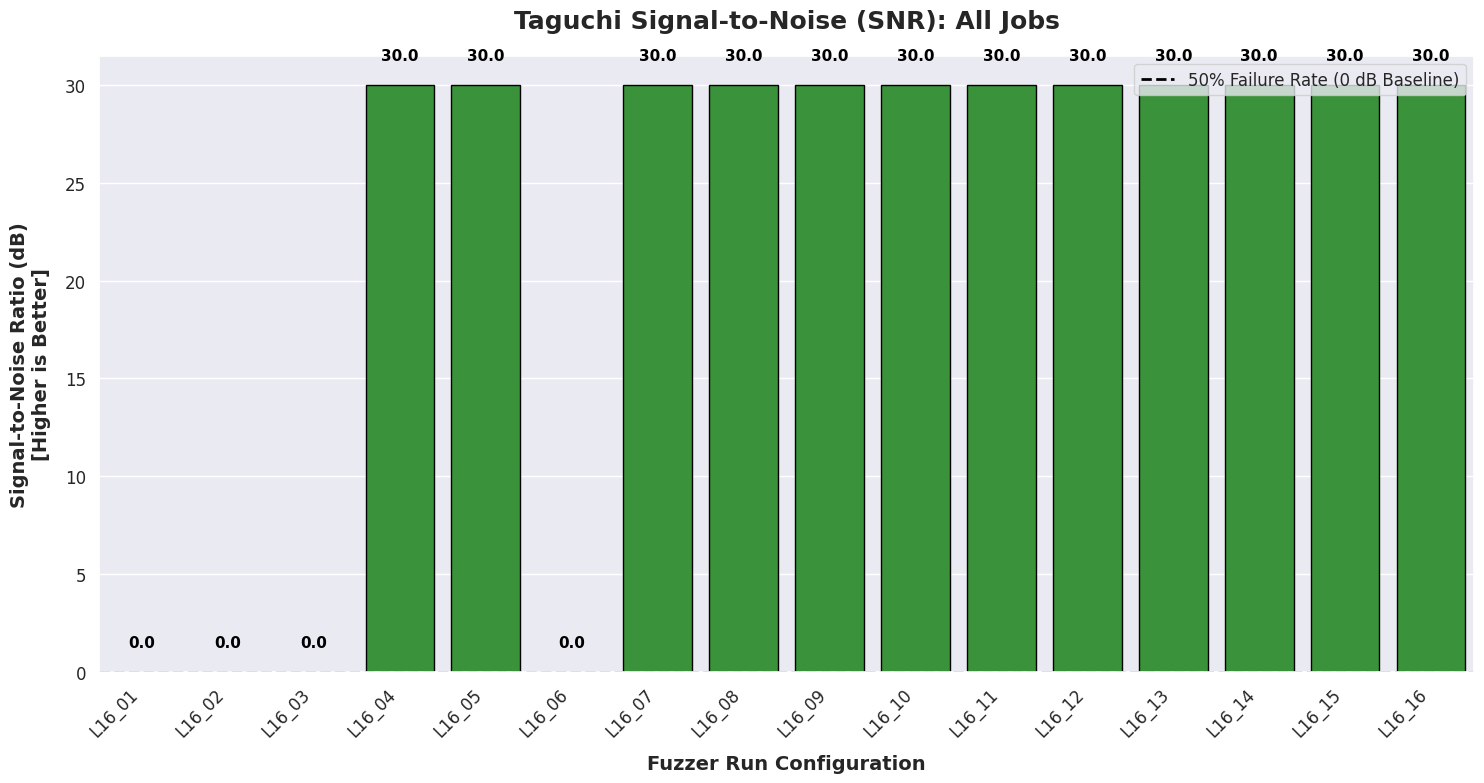

In [23]:
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to DuckDB and load the Gold reliability matrix
con = duckdb.connect()
gold_failure_path = '/content/lakehouse_archive/gold/configuration_reliability.parquet'
df_snr = con.execute(f"SELECT * FROM read_parquet('{gold_failure_path}')").df()

# --- PLOTTING ---
sns.set_theme(style="darkgrid")
plt.figure(figsize=(15, 8))

# Create a dynamic color palette: Green for stable (>0), Red for crashing (<0), Grey for coin-toss (==0)
colors = ['#2ca02c' if val > 0 else '#d62728' if val < 0 else '#7f7f7f' for val in df_snr['signal_to_noise_db']]

# Draw the bar chart
ax = sns.barplot(
    x='base_config',
    y='signal_to_noise_db',
    data=df_snr,
    palette=colors,
    edgecolor="black"
)

# Add a stark baseline at 0 dB
plt.axhline(0, color='black', linewidth=2, linestyle='--', label='50% Failure Rate (0 dB Baseline)')

# Add data labels directly onto the bars for quick reading
for p in ax.patches:
    height = p.get_height()
    # Nudge the label up or down depending on whether the bar goes up or down
    offset = 1.5 if height >= 0 else -2.5
    ax.annotate(f'{height:.1f}',
                (p.get_x() + p.get_width() / 2., height + offset),
                ha='center', va='center',
                fontsize=11, color='black', fontweight='bold')

# Formatting
plt.title('Taguchi Signal-to-Noise (SNR): All Jobs', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Fuzzer Run Configuration', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('Signal-to-Noise Ratio (dB)\n[Higher is Better]', fontsize=14, fontweight='bold', labelpad=10)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

### ANOVA test (successes and failures)

In [24]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

print("Calculating Analysis of Variance (ANOVA) for Taguchi Main Effects...")

# 1. Merge the hardware factors (matrix_df) with your SNR results (df_snr)
df_anova = pd.merge(matrix_df, df_snr, left_on='Run_ID', right_on='base_config')

# 2. Define the OLS model using the CORRECT column names from the merge
# We use C() to ensure the hardware parameters are treated as categorical factors
model_formula = 'signal_to_noise_db ~ C(CPU_Cores) + C(Memory_GB) + C(Bandwidth_MBps)'

# 3. Fit the model to your newly merged DataFrame
model = ols(model_formula, data=df_anova).fit()

# 4. Generate the ANOVA table (Type II is standard for orthogonal designs)
anova_table = sm.stats.anova_lm(model, typ=2)

# 5. Calculate Percentage Contribution (Rho) for your thesis
anova_table['sum_sq_total'] = anova_table['sum_sq'].sum()
anova_table['percentage_contribution'] = (anova_table['sum_sq'] / anova_table['sum_sq_total']) * 100

# Drop the total column for cleaner viewing
anova_table = anova_table.drop(columns=['sum_sq_total'])

# Clean up column names for presentation
anova_table.rename(columns={
    'sum_sq': 'Sum of Squares (SS)',
    'df': 'Degrees of Freedom (DF)',
    'F': 'F-Value',
    'PR(>F)': 'P-Value',
    'percentage_contribution': 'Contribution (%)'
}, inplace=True)

print(anova_table.round(4))

Calculating Analysis of Variance (ANOVA) for Taguchi Main Effects...
                   Sum of Squares (SS)  Degrees of Freedom (DF)  F-Value  \
C(CPU_Cores)                 1349.6090                      3.0      6.0   
C(Memory_GB)                  449.8697                      3.0      2.0   
C(Bandwidth_MBps)             449.8697                      3.0      2.0   
Residual                      449.8697                      6.0      NaN   

                   P-Value  Contribution (%)  
C(CPU_Cores)        0.0308           50.0000  
C(Memory_GB)        0.2156           16.6667  
C(Bandwidth_MBps)   0.2156           16.6667  
Residual               NaN           16.6667  


### Taguchi Factors (Main Effects - combined successes and failures)

Setting safety limits and mapping disk swap...
Extracting Taguchi main effects (SNR & Job Throughput) directly from Gold layer...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Extraction complete! Aggregated factor levels across 16 configurations. Rendering plot...


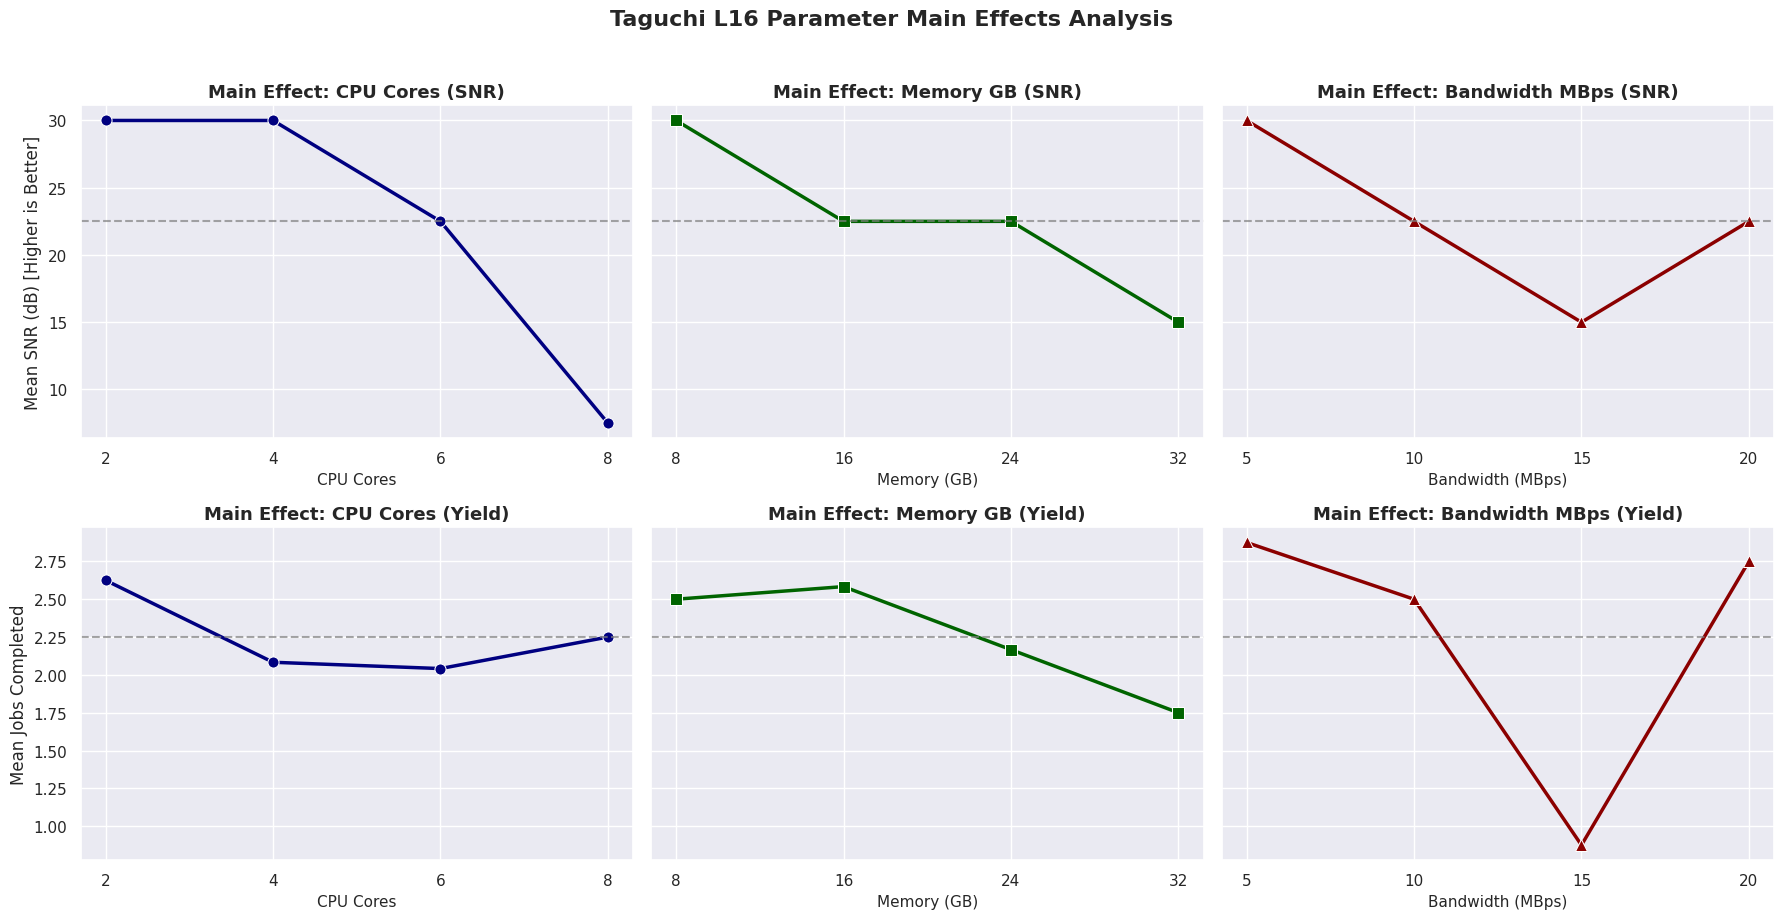

In [25]:
import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. GENERATE DYNAMIC TAGUCHI L16 MATRIX
# ==========================================
def generate_taguchi_l16_dataframe():
    cpu_levels = [8, 6, 4, 2]
    mem_levels = [32, 24, 16, 8]
    bw_levels = [20, 15, 10, 5]
    records = []

    # Using bitwise XOR to perfectly match the executed Bash runplan
    for i in range(16):
        col_A = i // 4
        col_C = i % 4
        col_B = col_A ^ col_C

        records.append({
            "Run_ID": f"L16_{i+1:02d}",
            "CPU_Cores": cpu_levels[col_A],
            "Memory_GB": mem_levels[col_B],
            "Bandwidth_MBps": bw_levels[col_C]
        })
    return pd.DataFrame(records)

# Create the DataFrame in local memory
matrix_df = generate_taguchi_l16_dataframe()

# ==========================================
# 2. CONFIGURE DUCKDB & RUN ANALYSIS
# ==========================================
sns.set_theme(style="darkgrid")
con = duckdb.connect()

print("Setting safety limits and mapping disk swap...")
con.execute("SET preserve_insertion_order = false;")
con.execute("PRAGMA memory_limit='6GB'")
con.execute("PRAGMA temp_directory='/content/duckdb_swap'")

gold_master_path = '/content/lakehouse_archive/gold/anomalies_master.parquet'
gold_reliability_path = '/content/lakehouse_archive/gold/configuration_reliability.parquet'

print("Extracting Taguchi main effects (SNR & Job Throughput) directly from Gold layer...")

# Vectorized Gold Extraction + Dynamic L16 Factor Level Mapping
duckdb_main_effects_query = f"""
WITH l16_matrix AS (
    SELECT
        Run_ID AS base_config,
        CPU_Cores AS cpu_cores,
        Memory_GB AS memory_gb,
        Bandwidth_MBps AS bandwidth_mbps
    FROM matrix_df
),
base_gold AS (
    SELECT
        UPPER(regexp_extract(run_name, '(?i)(L16_\\d{{2}})', 1)) AS base_config,
        run_name AS raw_run_name,
        timestamp,
        message
    FROM read_parquet('{gold_master_path}')
    WHERE message LIKE '%Jobs complete%'
),
session_gaps AS (
    SELECT
        base_config,
        raw_run_name,
        timestamp,
        message,
        CASE
            WHEN EPOCH(timestamp) - EPOCH(LAG(timestamp) OVER (PARTITION BY raw_run_name ORDER BY timestamp ASC)) > 1800
            THEN 1 ELSE 0
        END AS is_new_trial
    FROM base_gold
),
trial_indexed AS (
    SELECT
        base_config,
        raw_run_name,
        timestamp,
        message,
        SUM(is_new_trial) OVER (PARTITION BY raw_run_name ORDER BY timestamp ASC ROWS UNBOUNDED PRECEDING) + 1 AS trial_num
    FROM session_gaps
),
trial_timeline AS (
    SELECT
        base_config,
        raw_run_name,
        trial_num,
        (EPOCH(timestamp) - EPOCH(MIN(timestamp) OVER (PARTITION BY raw_run_name, trial_num))) / 60.0 AS elapsed_minutes,
        TRY_CAST(regexp_extract(message, 'Jobs complete \\((\\d+) success', 1) AS INT) +
        TRY_CAST(regexp_extract(message, '(\\d+) failed\\)', 1) AS INT) AS raw_jobs
    FROM trial_indexed
),
bounded_timeline AS (
    SELECT
        base_config,
        raw_run_name,
        trial_num,
        LEAST(elapsed_minutes, 1440.0) AS elapsed_minutes,
        raw_jobs
    FROM trial_timeline
    WHERE elapsed_minutes <= 1440.0
),
trial_summaries AS (
    SELECT
        base_config,
        MAX(raw_jobs) AS total_jobs
    FROM bounded_timeline
    GROUP BY base_config, raw_run_name, trial_num
),
mean_jobs_per_config AS (
    SELECT
        base_config,
        AVG(total_jobs) AS mean_jobs
    FROM trial_summaries
    GROUP BY base_config
),
reliability AS (
    SELECT
        base_config,
        signal_to_noise_db
    FROM read_parquet('{gold_reliability_path}')
)
SELECT
    m.base_config,
    m.cpu_cores,
    m.memory_gb,
    m.bandwidth_mbps,
    COALESCE(r.signal_to_noise_db, 0.0) AS signal_to_noise_db,
    COALESCE(j.mean_jobs, 0.0) AS mean_jobs
FROM l16_matrix m
LEFT JOIN reliability r ON m.base_config = r.base_config
LEFT JOIN mean_jobs_per_config j ON m.base_config = j.base_config
ORDER BY m.base_config ASC;
"""

df_me = con.execute(duckdb_main_effects_query).df()

print(f"Extraction complete! Aggregated factor levels across {len(df_me)} configurations. Rendering plot...")

# ==========================================
# 3. PLOTTING: TAGUCHI MAIN EFFECTS (2x3 GRID)
# ==========================================
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 9), sharey='row')

# Overall Mean Reference Lines
overall_snr_mean = df_me['signal_to_noise_db'].mean()
overall_jobs_mean = df_me['mean_jobs'].mean()

# --- ROW 1: MAIN EFFECTS FOR SIGNAL-TO-NOISE RATIO (dB) ---
# CPU Cores
cpu_snr = df_me.groupby('cpu_cores')['signal_to_noise_db'].mean().reset_index()
sns.lineplot(data=cpu_snr, x='cpu_cores', y='signal_to_noise_db', marker='o', markersize=8, linewidth=2.5, ax=axes[0, 0], color='navy')
axes[0, 0].axhline(overall_snr_mean, color='gray', linestyle='--', alpha=0.7)
axes[0, 0].set_title('Main Effect: CPU Cores (SNR)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('CPU Cores', fontsize=11)
axes[0, 0].set_ylabel('Mean SNR (dB) [Higher is Better]', fontsize=12)
axes[0, 0].set_xticks([2, 4, 6, 8])

# Memory (GB)
mem_snr = df_me.groupby('memory_gb')['signal_to_noise_db'].mean().reset_index()
sns.lineplot(data=mem_snr, x='memory_gb', y='signal_to_noise_db', marker='s', markersize=8, linewidth=2.5, ax=axes[0, 1], color='darkgreen')
axes[0, 1].axhline(overall_snr_mean, color='gray', linestyle='--', alpha=0.7)
axes[0, 1].set_title('Main Effect: Memory GB (SNR)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Memory (GB)', fontsize=11)
axes[0, 1].set_xticks([8, 16, 24, 32])

# Bandwidth (MBps)
bw_snr = df_me.groupby('bandwidth_mbps')['signal_to_noise_db'].mean().reset_index()
sns.lineplot(data=bw_snr, x='bandwidth_mbps', y='signal_to_noise_db', marker='^', markersize=8, linewidth=2.5, ax=axes[0, 2], color='darkred')
axes[0, 2].axhline(overall_snr_mean, color='gray', linestyle='--', alpha=0.7)
axes[0, 2].set_title('Main Effect: Bandwidth MBps (SNR)', fontsize=13, fontweight='bold')
axes[0, 2].set_xlabel('Bandwidth (MBps)', fontsize=11)
axes[0, 2].set_xticks([5, 10, 15, 20])


# --- ROW 2: MAIN EFFECTS FOR MEAN JOB COMPLETIONS ---
# CPU Cores
cpu_jobs = df_me.groupby('cpu_cores')['mean_jobs'].mean().reset_index()
sns.lineplot(data=cpu_jobs, x='cpu_cores', y='mean_jobs', marker='o', markersize=8, linewidth=2.5, ax=axes[1, 0], color='navy')
axes[1, 0].axhline(overall_jobs_mean, color='gray', linestyle='--', alpha=0.7)
axes[1, 0].set_title('Main Effect: CPU Cores (Yield)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('CPU Cores', fontsize=11)
axes[1, 0].set_ylabel('Mean Jobs Completed', fontsize=12)
axes[1, 0].set_xticks([2, 4, 6, 8])

# Memory (GB)
mem_jobs = df_me.groupby('memory_gb')['mean_jobs'].mean().reset_index()
sns.lineplot(data=mem_jobs, x='memory_gb', y='mean_jobs', marker='s', markersize=8, linewidth=2.5, ax=axes[1, 1], color='darkgreen')
axes[1, 1].axhline(overall_jobs_mean, color='gray', linestyle='--', alpha=0.7)
axes[1, 1].set_title('Main Effect: Memory GB (Yield)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Memory (GB)', fontsize=11)
axes[1, 1].set_xticks([8, 16, 24, 32])

# Bandwidth (MBps)
bw_jobs = df_me.groupby('bandwidth_mbps')['mean_jobs'].mean().reset_index()
sns.lineplot(data=bw_jobs, x='bandwidth_mbps', y='mean_jobs', marker='^', markersize=8, linewidth=2.5, ax=axes[1, 2], color='darkred')
axes[1, 2].axhline(overall_jobs_mean, color='gray', linestyle='--', alpha=0.7)
axes[1, 2].set_title('Main Effect: Bandwidth MBps (Yield)', fontsize=13, fontweight='bold')
axes[1, 2].set_xlabel('Bandwidth (MBps)', fontsize=11)
axes[1, 2].set_xticks([5, 10, 15, 20])

plt.suptitle('Taguchi L16 Parameter Main Effects Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Generate Koopman Operator decay charts (combined successes and failures)

/tmp/ipykernel_2238/661535387.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


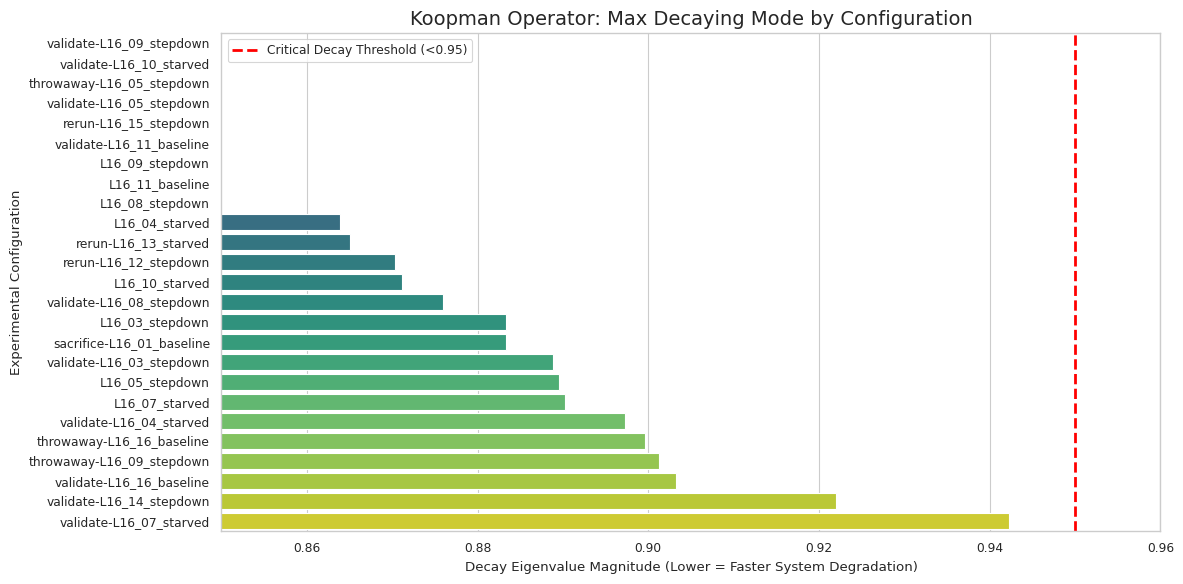

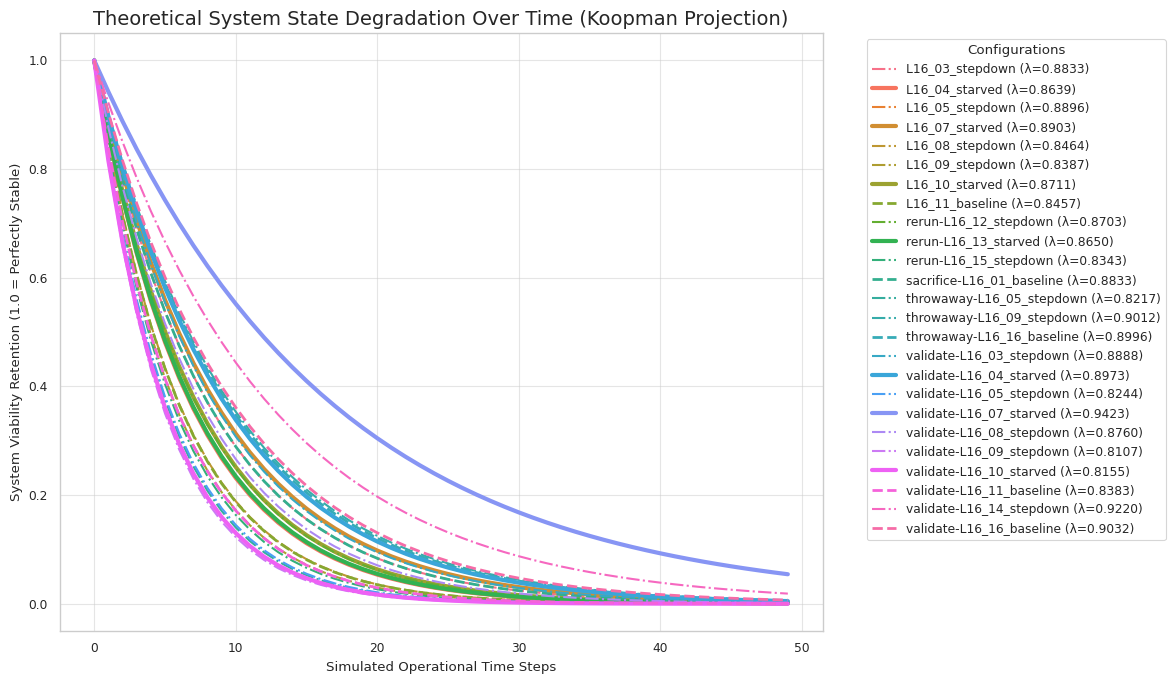

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style for academic plotting
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14})

# ==========================================
# GRAPH 1: Decaying Mode Comparison (Bar Chart)
# ==========================================
plt.figure(figsize=(12, 6))

# Sort by decay mode so the worst degrading systems are at the top/bottom
df_sorted = df_koopman_summary.sort_values('Decaying Mode (|lambda_decay|)', ascending=True)

# Create a bar plot
ax = sns.barplot(
    data=df_sorted,
    x='Decaying Mode (|lambda_decay|)',
    y='Run Config',
    palette='viridis'
)

# Add a vertical red line to show the "Critical Decay Threshold"
plt.axvline(x=0.95, color='red', linestyle='--', linewidth=2, label='Critical Decay Threshold (<0.95)')

plt.title("Koopman Operator: Max Decaying Mode by Configuration")
plt.xlabel("Decay Eigenvalue Magnitude (Lower = Faster System Degradation)")
plt.ylabel("Experimental Configuration")
plt.xlim(0.85, 0.96) # Zoom in on the variance
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# GRAPH 2: Theoretical Decay Trajectories
# ==========================================
plt.figure(figsize=(12, 7))

# Simulate 50 time steps of system operation
t_steps = np.arange(0, 50)

# Define custom colors/markers to separate the configs visually
colors = sns.color_palette("husl", len(df_koopman_summary))

for idx, row in df_koopman_summary.iterrows():
    run_name = row['Run Config']
    lam = row['Decaying Mode (|lambda_decay|)']

    # Calculate the theoretical Koopman trajectory: x(t) = lambda^t
    trajectory = np.power(lam, t_steps)

    # Emphasize the 'Starved' configs vs 'Baseline'
    if 'starved' in run_name.lower():
        line_style = '-'
        line_width = 3
    elif 'baseline' in run_name.lower():
        line_style = '--'
        line_width = 2
    else:
        line_style = '-.'
        line_width = 1.5

    plt.plot(t_steps, trajectory, label=f"{run_name} (λ={lam:.4f})",
             linestyle=line_style, linewidth=line_width, color=colors[idx])

plt.title("Theoretical System State Degradation Over Time (Koopman Projection)")
plt.xlabel("Simulated Operational Time Steps")
plt.ylabel("System Viability Retention (1.0 = Perfectly Stable)")

# Add a grid and a legend outside the plot
plt.grid(True, alpha=0.5)
plt.legend(title="Configurations", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Generate Koopman Operator decay charts (all runs)

Extracting 1D Rolling SNR state and grouping by base configuration...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/tmp/ipykernel_2238/2533061300.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


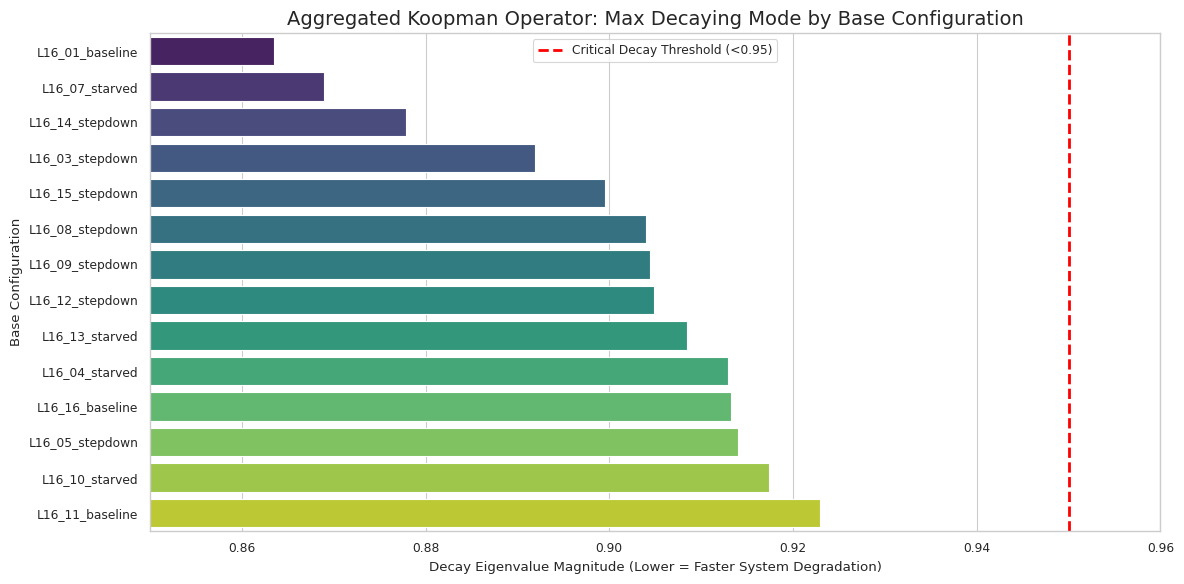

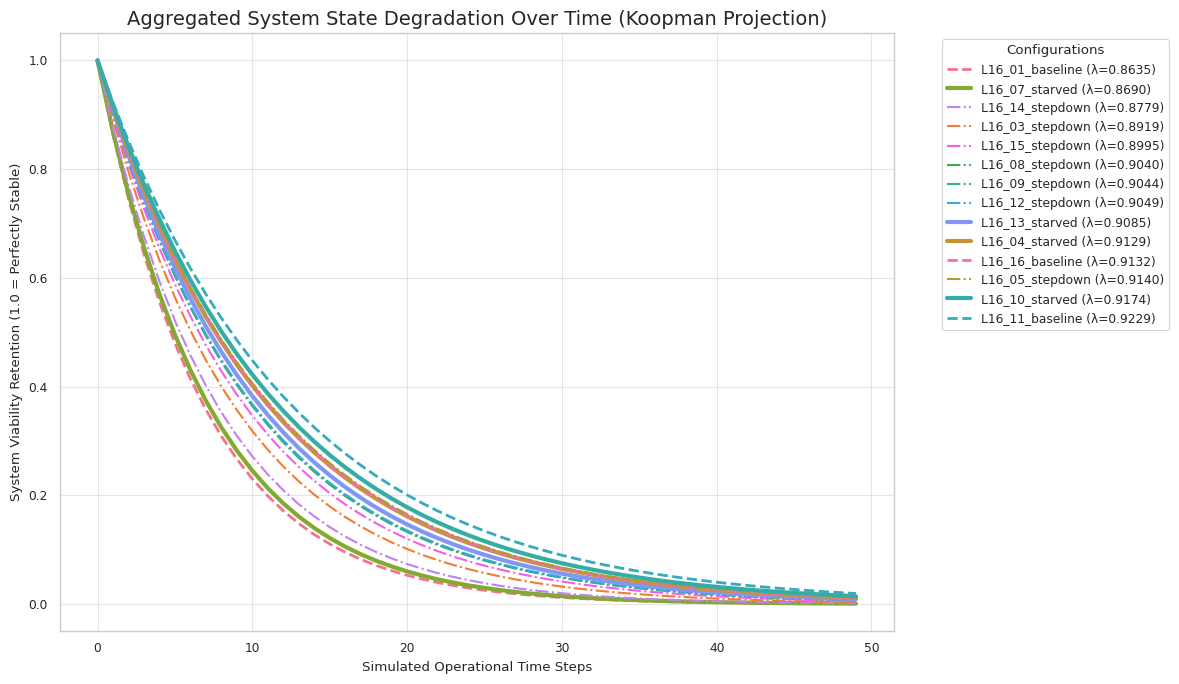

In [27]:
import duckdb
import numpy as np
import pandas as pd
import scipy.linalg as la
import matplotlib.pyplot as plt
import seaborn as sns
import re

# ==========================================
# 1. LOAD & CLEAN DATA
# ==========================================
con = duckdb.connect()
gold_rolling_path = '/content/lakehouse_archive/gold/rolling_reliability.parquet'

print("Extracting 1D Rolling SNR state and grouping by base configuration...")

df_logs = con.execute(f"SELECT * FROM read_parquet('{gold_rolling_path}') ORDER BY experiment_name ASC, rolling_total_runs ASC").df()

def clean_config_name(name):
    """Strips run counters like ' (1)' and prefixes like 'validate-' to find the base config"""
    # Remove suffix counters e.g., " (1)", " (2)"
    name = re.sub(r'\s*\(\d+\)$', '', name)
    # Remove common execution prefixes
    name = re.sub(r'^(validate-|rerun-|throwaway-|sacrifice-)', '', name, flags=re.IGNORECASE)
    return name
# Create the unified grouping column
df_logs['base_config'] = df_logs['experiment_name'].apply(clean_config_name)


# ==========================================
# 2. KOOPMAN MATH (MULTI-TRAJECTORY)
# ==========================================
def get_hankel_matrices(snr_series, delay_embedding_dim=15):
    """Builds the delay-embedded matrix for a SINGLE continuous run"""
    M_total = len(snr_series)
    if M_total < delay_embedding_dim + 2:
        return None, None

    hankel_blocks = []
    for d in range(delay_embedding_dim):
        hankel_blocks.append(snr_series[d : M_total - delay_embedding_dim + d + 1])

    Z = np.vstack(hankel_blocks)
    return Z[:, :-1], Z[:, 1:]  # Psi_X, Psi_Y

def analyze_koopman_grouped(group_df, delay_embedding_dim=15):
    """Calculates Koopman modes across MULTIPLE independent trajectories"""
    all_Psi_X, all_Psi_Y = [], []

    # Process each isolated run so we don't create fake jumps between runs
    for run_name, sub_df in group_df.groupby('experiment_name'):
        snr_series = sub_df.sort_values('rolling_total_runs')['rolling_signal_to_noise_db'].values
        Psi_X, Psi_Y = get_hankel_matrices(snr_series, delay_embedding_dim)

        if Psi_X is not None:
            all_Psi_X.append(Psi_X)
            all_Psi_Y.append(Psi_Y)

    if not all_Psi_X:
        return {"Spectral Radius": np.nan, "Max Decaying Mode": np.nan, "Mean Residual Error": np.nan, "Koopman Verdict": "Insufficient Data"}

    # Horizontally stack all independent matrices into one massive observable space
    Psi_X = np.hstack(all_Psi_X)
    Psi_Y = np.hstack(all_Psi_Y)

    # Dynamic Mode Decomposition (SVD)
    U, S, Vh = la.svd(Psi_X, full_matrices=False)
    r = np.sum(S > 1e-5 * S[0])

    if r == 0:
        return {"Spectral Radius": 0.0, "Max Decaying Mode": 0.0, "Mean Residual Error": 0.0, "Koopman Verdict": "Flatline State"}

    U_r, S_r, Vh_r = U[:, :r], np.diag(S[:r]), Vh[:r, :]

    # Reduced Koopman Operator Matrix
    K_r = np.conj(U_r.T) @ Psi_Y @ np.conj(Vh_r.T) @ la.inv(S_r)
    evals, evecs = la.eig(K_r)

    # Residuals
    residuals = []
    for i, lam in enumerate(evals):
        v_i = evecs[:, i]
        phi_x = Psi_X @ np.conj(Vh_r.T) @ v_i
        phi_y = Psi_Y @ np.conj(Vh_r.T) @ v_i
        residuals.append(la.norm(phi_y - lam * phi_x) / (la.norm(phi_x) + 1e-12))

    eval_mags = np.abs(evals)
    spectral_radius = np.max(eval_mags)
    decaying_modes = eval_mags[eval_mags < 0.999]
    max_decay = np.max(decaying_modes) if len(decaying_modes) > 0 else 1.0
    mean_res = np.mean(residuals)

    if spectral_radius >= 0.98 and spectral_radius <= 1.02 and mean_res < 0.25:
        verdict = "VERIFIED STABLE (Run Viable)"
    elif max_decay < 0.95 or mean_res >= 0.25:
        verdict = "DECAY DETECTED (Failure / Contention Risk)"
    else:
        verdict = "UNSTABLE OSCILLATION"

    return {
        "Spectral Radius": round(float(spectral_radius), 4),
        "Max Decaying Mode": round(float(max_decay), 4),
        "Mean Residual Error": round(float(mean_res), 4),
        "Koopman Verdict": verdict
    }

# Run the unified groupings
results = []
for base_config, group in df_logs.groupby('base_config'):
    metrics = analyze_koopman_grouped(group)
    results.append({
        "Run Config": base_config,
        "Total Snapshots": len(group),
        "Spectral Radius (|lambda_max|)": metrics["Spectral Radius"],
        "Decaying Mode (|lambda_decay|)": metrics["Max Decaying Mode"],
        "Residual Error (ResDMD)": metrics["Mean Residual Error"],
        "Koopman Viability Verdict": metrics["Koopman Verdict"]
    })

df_koopman_summary = pd.DataFrame(results)


# ==========================================
# 3. PLOTTING AGGREGATED DATA
# ==========================================
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14})

# --- GRAPH 1: Bar Chart ---
plt.figure(figsize=(12, 6))
df_sorted = df_koopman_summary.sort_values('Decaying Mode (|lambda_decay|)', ascending=True)

ax = sns.barplot(
    data=df_sorted,
    x='Decaying Mode (|lambda_decay|)',
    y='Run Config',
    palette='viridis'
)

plt.axvline(x=0.95, color='red', linestyle='--', linewidth=2, label='Critical Decay Threshold (<0.95)')
plt.title("Aggregated Koopman Operator: Max Decaying Mode by Base Configuration")
plt.xlabel("Decay Eigenvalue Magnitude (Lower = Faster System Degradation)")
plt.ylabel("Base Configuration")
plt.xlim(0.85, 0.96)
plt.legend()
plt.tight_layout()
plt.show()

# --- GRAPH 2: Theoretical Trajectories ---
plt.figure(figsize=(12, 7))
t_steps = np.arange(0, 50)
colors = sns.color_palette("husl", len(df_sorted))

for idx, row in df_sorted.iterrows():
    run_name = row['Run Config']
    lam = row['Decaying Mode (|lambda_decay|)']
    trajectory = np.power(lam, t_steps)

    if 'starved' in run_name.lower():
        line_style, line_width = '-', 3
    elif 'baseline' in run_name.lower():
        line_style, line_width = '--', 2
    else:
        line_style, line_width = '-.', 1.5

    plt.plot(t_steps, trajectory, label=f"{run_name} (λ={lam:.4f})",
             linestyle=line_style, linewidth=line_width, color=colors[idx])

plt.title("Aggregated System State Degradation Over Time (Koopman Projection)")
plt.xlabel("Simulated Operational Time Steps")
plt.ylabel("System Viability Retention (1.0 = Perfectly Stable)")
plt.grid(True, alpha=0.5)
plt.legend(title="Configurations", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Modified signal-to-noise chart (job failures separated from successes)

Calculating Job Execution Signal-to-Noise Ratio (SNR)...


/tmp/ipykernel_2238/909100652.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


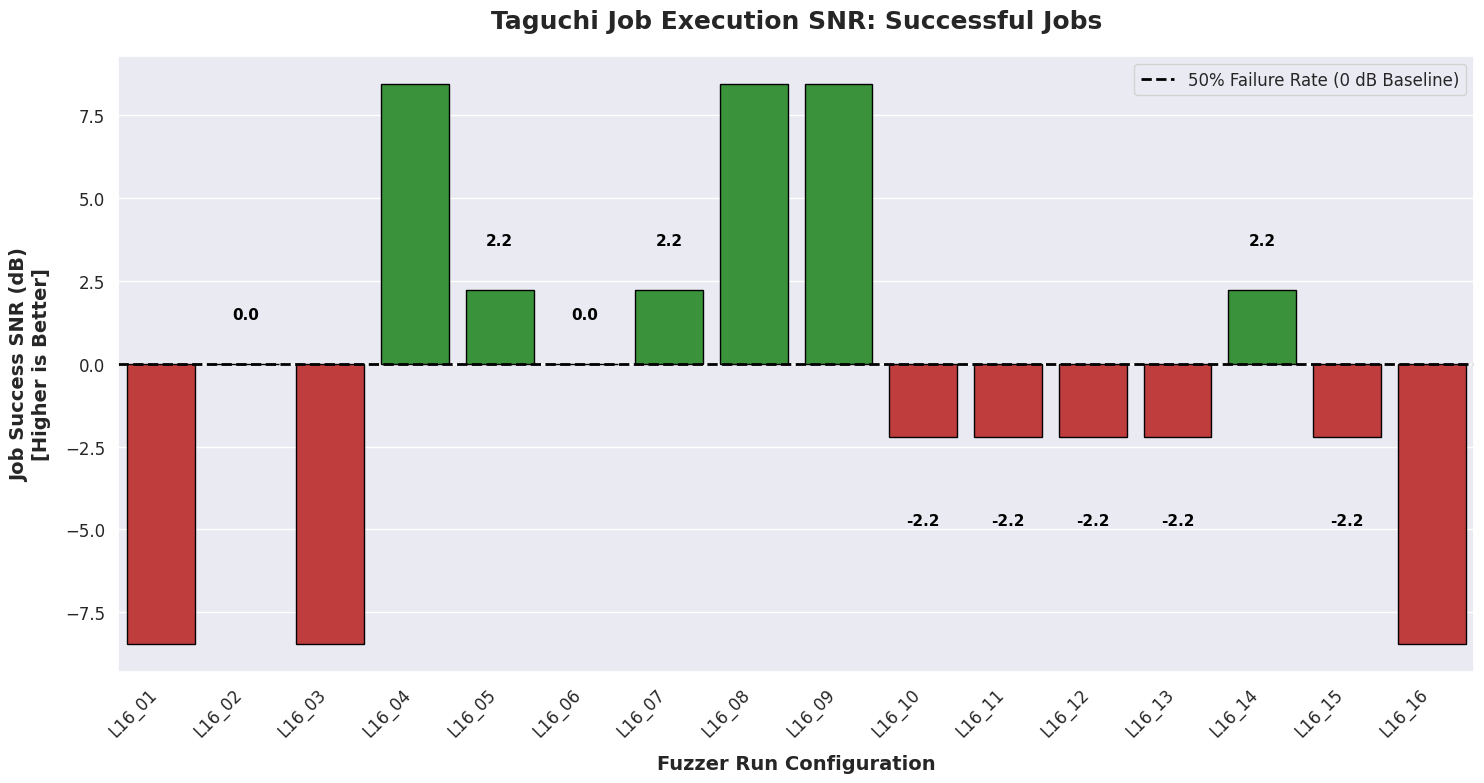

In [28]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. GENERATE DYNAMIC TAGUCHI L16 MATRIX
# ==========================================
def generate_taguchi_l16_dataframe():
    records = []
    # Using bitwise XOR to match the physical array
    for i in range(16):
        records.append({"Run_ID": f"L16_{i+1:02d}"})
    return pd.DataFrame(records)

matrix_df = generate_taguchi_l16_dataframe()

# ==========================================
# 2. CONFIGURE DUCKDB & RUN ANALYSIS
# ==========================================
con = duckdb.connect()
# NOTE: If this flatlines at 0.0, change this path to 'anomalies_master.parquet'
gold_metrics_path = '/content/lakehouse_archive/gold/system_metrics_master.parquet'

print("Calculating Job Execution Signal-to-Noise Ratio (SNR)...")

duckdb_job_snr_query = f"""
WITH l16_matrix AS (
    SELECT Run_ID AS base_config FROM matrix_df
),
base_gold AS (
    SELECT
        UPPER(regexp_extract(run_name, '(?i)(L16_\\d{{2}})', 1)) AS base_config,
        run_name,
        timestamp,
        message
    FROM read_parquet('{gold_metrics_path}')
    WHERE message LIKE '%Jobs complete%'
      AND timestamp >= '2026-06-27'
),
latest_logs AS (
    -- Isolate the final 'Jobs complete' update per run
    SELECT base_config, run_name, message
    FROM base_gold
    QUALIFY ROW_NUMBER() OVER(PARTITION BY run_name ORDER BY timestamp DESC) = 1
),
parsed_metrics AS (
    SELECT
        base_config,
        -- Attempt Format 1: "Jobs complete (...): X/Y"
        TRY_CAST(regexp_extract(message, 'Jobs complete \\(.*?\\):\\s*(\\d+)/(\\d+)', 1) AS DOUBLE) AS s_fmt1,
        TRY_CAST(regexp_extract(message, 'Jobs complete \\(.*?\\):\\s*(\\d+)/(\\d+)', 2) AS DOUBLE) AS t_fmt1,

        -- Attempt Format 2: "Jobs complete (X success, Y failed)"
        TRY_CAST(regexp_extract(message, 'Jobs complete \\((\\d+) success', 1) AS DOUBLE) AS s_fmt2,
        TRY_CAST(regexp_extract(message, '(\\d+) failed\\)', 1) AS DOUBLE) AS f_fmt2
    FROM latest_logs
),
unified_metrics AS (
    SELECT
        base_config,
        COALESCE(s_fmt1, s_fmt2, 0.0) AS successes,
        COALESCE(t_fmt1, (s_fmt2 + f_fmt2), 0.0) AS total_jobs
    FROM parsed_metrics
),
config_aggregates AS (
    SELECT
        base_config,
        SUM(successes) AS total_successes,
        SUM(total_jobs - successes) AS total_failures
    FROM unified_metrics
    WHERE base_config IS NOT NULL AND base_config != ''
    GROUP BY base_config
),
job_snr_calc AS (
    SELECT
        base_config,
        total_successes,
        total_failures,
        10 * LOG10((total_successes + 0.5) / (total_failures + 0.5)) AS job_snr_db
    FROM config_aggregates
)
SELECT
    m.base_config,
    COALESCE(j.total_successes, 0.0) AS total_successes,
    COALESCE(j.total_failures, 0.0) AS total_failures,
    COALESCE(j.job_snr_db, 0.0) AS job_snr_db
FROM l16_matrix m
LEFT JOIN job_snr_calc j ON m.base_config = j.base_config
ORDER BY m.base_config ASC;
"""

df_job_snr = con.execute(duckdb_job_snr_query).df()

# ==========================================
# 3. PLOTTING
# ==========================================
sns.set_theme(style="darkgrid")
plt.figure(figsize=(15, 8))

# Dynamic color palette will no longer fail since we guarantee 16 rows
colors = ['#2ca02c' if val > 0 else '#d62728' if val < 0 else '#7f7f7f' for val in df_job_snr['job_snr_db']]

ax = sns.barplot(
    x='base_config',
    y='job_snr_db',
    data=df_job_snr,
    palette=colors,
    edgecolor="black"
)

# Stark baseline at 0 dB
plt.axhline(0, color='black', linewidth=2, linestyle='--', label='50% Failure Rate (0 dB Baseline)')

# Add data labels safely
for p in ax.patches:
    height = p.get_height()
    offset = 1.5 if height >= 0 else -2.5
    ax.annotate(f'{height:.1f}',
                (p.get_x() + p.get_width() / 2., height + offset),
                ha='center', va='center',
                fontsize=11, color='black', fontweight='bold')

plt.title('Taguchi Job Execution SNR: Successful Jobs', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Fuzzer Run Configuration', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('Job Success SNR (dB)\n[Higher is Better]', fontsize=14, fontweight='bold', labelpad=10)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

NB takes approx 1 hour 40 minutes to reach this part

### ANOVA (job failures separated from successes)

In [29]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

print("Calculating Analysis of Variance (ANOVA) for Taguchi Main Effects (Successes only)...")

# THE FIX: Merge the calculated SNR into the main effects (df_me) dataframe
df_me = pd.merge(df_me, df_job_snr[['base_config', 'job_snr_db']], left_on='base_config', right_on='base_config', how='left')

# Now the formula will find ALL columns in the same dataframe
model_formula = 'job_snr_db ~ C(cpu_cores) + C(memory_gb) + C(bandwidth_mbps)'
model = ols(model_formula, data=df_me).fit()

# Generate the ANOVA table (Type II is standard for orthogonal designs)
anova_table = sm.stats.anova_lm(model, typ=2)

# Calculate Percentage Contribution (Rho) for your thesis
anova_table['sum_sq_total'] = anova_table['sum_sq'].sum()
anova_table['percentage_contribution'] = (anova_table['sum_sq'] / anova_table['sum_sq_total']) * 100

# Drop the total column for cleaner viewing
anova_table = anova_table.drop(columns=['sum_sq_total'])

# Clean up column names for presentation
anova_table.rename(columns={
    'sum_sq': 'Sum of Squares (SS)',
    'df': 'Degrees of Freedom (DF)',
    'F': 'F-Value',
    'PR(>F)': 'P-Value',
    'percentage_contribution': 'Contribution (%)'
}, inplace=True)

print(anova_table.round(4))

Calculating Analysis of Variance (ANOVA) for Taguchi Main Effects (Successes only)...
                   Sum of Squares (SS)  Degrees of Freedom (DF)  F-Value  \
C(cpu_cores)                   87.4146                      3.0   0.8218   
C(memory_gb)                  129.5683                      3.0   1.2181   
C(bandwidth_mbps)              36.9400                      3.0   0.3473   
Residual                      212.7347                      6.0      NaN   

                   P-Value  Contribution (%)  
C(cpu_cores)        0.5277           18.7321  
C(memory_gb)        0.3814           27.7652  
C(bandwidth_mbps)   0.7929            7.9159  
Residual               NaN           45.5869  


### Modified Taguchi main effects (job failures separated from successes)

Setting safety limits...
Extracting Taguchi main effects (Job Execution SNR & Successful Throughput)...


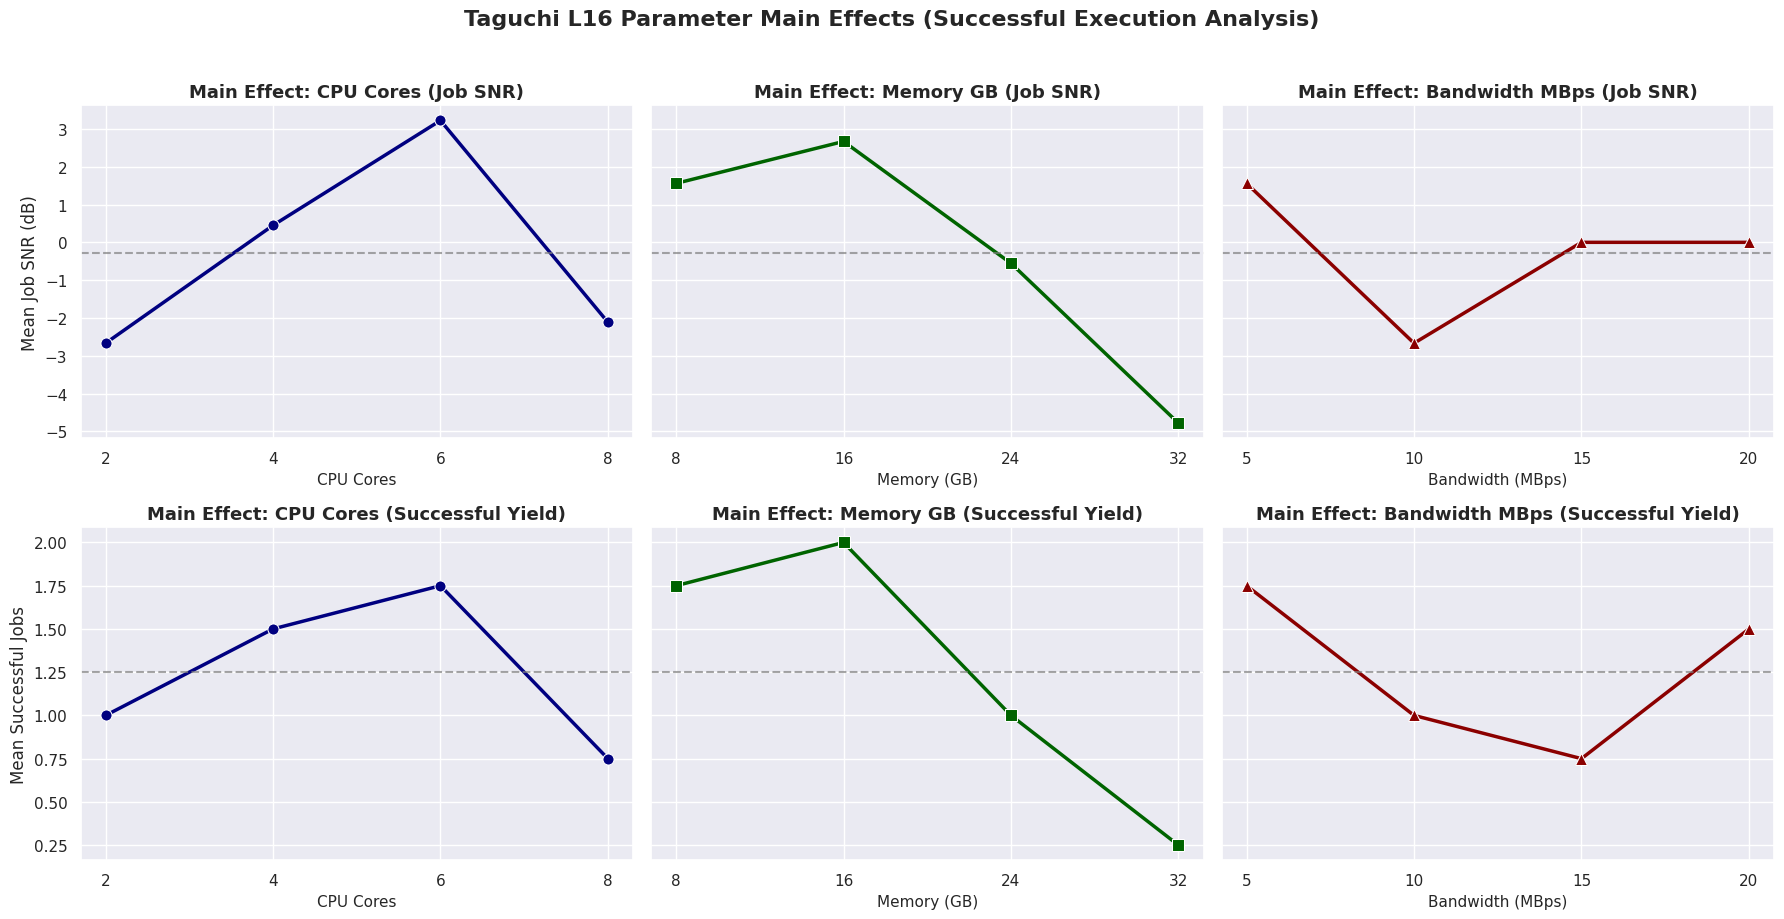

In [30]:
import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. GENERATE DYNAMIC TAGUCHI L16 MATRIX
# ==========================================
def generate_taguchi_l16_dataframe():
    cpu_levels = [8, 6, 4, 2]
    mem_levels = [32, 24, 16, 8]
    bw_levels = [20, 15, 10, 5]
    records = []

    # Using bitwise XOR to perfectly match the executed Bash runplan
    for i in range(16):
        col_A = i // 4
        col_C = i % 4
        col_B = col_A ^ col_C

        records.append({
            "Run_ID": f"L16_{i+1:02d}",
            "CPU_Cores": cpu_levels[col_A],
            "Memory_GB": mem_levels[col_B],
            "Bandwidth_MBps": bw_levels[col_C]
        })
    return pd.DataFrame(records)

# Create the DataFrame in local memory
matrix_df = generate_taguchi_l16_dataframe()

# ==========================================
# 2. CONFIGURE DUCKDB & RUN ANALYSIS
# ==========================================
sns.set_theme(style="darkgrid")
con = duckdb.connect()

print("Setting safety limits...")
con.execute("SET preserve_insertion_order = false;")
con.execute("PRAGMA memory_limit='6GB'")
con.execute("PRAGMA temp_directory='/content/duckdb_swap'")

gold_metrics_path = '/content/lakehouse_archive/gold/system_metrics_master.parquet'
print("Extracting Taguchi main effects (Job Execution SNR & Successful Throughput)...")

# Notice the 'l16_matrix' CTE simply SELECTs directly from the Python 'matrix_df' variable
duckdb_main_effects_query = f"""
WITH l16_matrix AS (
    SELECT
        Run_ID AS base_config,
        CPU_Cores AS cpu_cores,
        Memory_GB AS memory_gb,
        Bandwidth_MBps AS bandwidth_mbps
    FROM matrix_df
),
base_gold AS (
    SELECT
        UPPER(regexp_extract(run_name, '(?i)(L16_\\d{{2}})', 1)) AS base_config,
        run_name,
        timestamp,
        message
    FROM read_parquet('{gold_metrics_path}')
    WHERE message LIKE '%Jobs complete%' AND timestamp >= '2026-06-27'
),
latest_logs AS (
    SELECT base_config, run_name, message
    FROM base_gold
    QUALIFY ROW_NUMBER() OVER(PARTITION BY run_name ORDER BY timestamp DESC) = 1
),
parsed_metrics AS (
    SELECT
        base_config,
        TRY_CAST(regexp_extract(message, 'Jobs complete \\(.*?\\):\\s*(\\d+)/(\\d+)', 1) AS DOUBLE) AS successes,
        TRY_CAST(regexp_extract(message, 'Jobs complete \\(.*?\\):\\s*(\\d+)/(\\d+)', 2) AS DOUBLE) AS total_jobs
    FROM latest_logs
),
config_aggregates AS (
    SELECT
        base_config,
        SUM(successes) AS total_successes,
        SUM(total_jobs - successes) AS total_failures,
        AVG(successes) AS mean_successes
    FROM parsed_metrics
    WHERE base_config IS NOT NULL AND base_config != ''
    GROUP BY base_config
),
job_snr_calc AS (
    SELECT
        base_config,
        mean_successes,
        10 * LOG10((total_successes + 0.5) / (total_failures + 0.5)) AS job_snr_db
    FROM config_aggregates
)
SELECT
    m.base_config,
    m.cpu_cores,
    m.memory_gb,
    m.bandwidth_mbps,
    COALESCE(j.job_snr_db, 0.0) AS job_snr_db,
    COALESCE(j.mean_successes, 0.0) AS mean_successes
FROM l16_matrix m
LEFT JOIN job_snr_calc j ON m.base_config = j.base_config
ORDER BY m.base_config ASC;
"""

df_me = con.execute(duckdb_main_effects_query).df()

# ==========================================
# 3. PLOTTING: TAGUCHI MAIN EFFECTS (2x3 GRID)
# ==========================================
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 9), sharey='row')

overall_snr_mean = df_me['job_snr_db'].mean()
overall_jobs_mean = df_me['mean_successes'].mean()

# --- ROW 1: MAIN EFFECTS FOR JOB EXECUTION SNR (dB) ---
cpu_snr = df_me.groupby('cpu_cores')['job_snr_db'].mean().reset_index()
sns.lineplot(data=cpu_snr, x='cpu_cores', y='job_snr_db', marker='o', markersize=8, linewidth=2.5, ax=axes[0, 0], color='navy')
axes[0, 0].axhline(overall_snr_mean, color='gray', linestyle='--', alpha=0.7)
axes[0, 0].set_title('Main Effect: CPU Cores (Job SNR)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('CPU Cores', fontsize=11)
axes[0, 0].set_ylabel('Mean Job SNR (dB)', fontsize=12)
axes[0, 0].set_xticks([2, 4, 6, 8])

mem_snr = df_me.groupby('memory_gb')['job_snr_db'].mean().reset_index()
sns.lineplot(data=mem_snr, x='memory_gb', y='job_snr_db', marker='s', markersize=8, linewidth=2.5, ax=axes[0, 1], color='darkgreen')
axes[0, 1].axhline(overall_snr_mean, color='gray', linestyle='--', alpha=0.7)
axes[0, 1].set_title('Main Effect: Memory GB (Job SNR)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Memory (GB)', fontsize=11)
axes[0, 1].set_xticks([8, 16, 24, 32])

bw_snr = df_me.groupby('bandwidth_mbps')['job_snr_db'].mean().reset_index()
sns.lineplot(data=bw_snr, x='bandwidth_mbps', y='job_snr_db', marker='^', markersize=8, linewidth=2.5, ax=axes[0, 2], color='darkred')
axes[0, 2].axhline(overall_snr_mean, color='gray', linestyle='--', alpha=0.7)
axes[0, 2].set_title('Main Effect: Bandwidth MBps (Job SNR)', fontsize=13, fontweight='bold')
axes[0, 2].set_xlabel('Bandwidth (MBps)', fontsize=11)
axes[0, 2].set_xticks([5, 10, 15, 20])

# --- ROW 2: MAIN EFFECTS FOR MEAN SUCCESSFUL JOBS ---
cpu_jobs = df_me.groupby('cpu_cores')['mean_successes'].mean().reset_index()
sns.lineplot(data=cpu_jobs, x='cpu_cores', y='mean_successes', marker='o', markersize=8, linewidth=2.5, ax=axes[1, 0], color='navy')
axes[1, 0].axhline(overall_jobs_mean, color='gray', linestyle='--', alpha=0.7)
axes[1, 0].set_title('Main Effect: CPU Cores (Successful Yield)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('CPU Cores', fontsize=11)
axes[1, 0].set_ylabel('Mean Successful Jobs', fontsize=12)
axes[1, 0].set_xticks([2, 4, 6, 8])

mem_jobs = df_me.groupby('memory_gb')['mean_successes'].mean().reset_index()
sns.lineplot(data=mem_jobs, x='memory_gb', y='mean_successes', marker='s', markersize=8, linewidth=2.5, ax=axes[1, 1], color='darkgreen')
axes[1, 1].axhline(overall_jobs_mean, color='gray', linestyle='--', alpha=0.7)
axes[1, 1].set_title('Main Effect: Memory GB (Successful Yield)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Memory (GB)', fontsize=11)
axes[1, 1].set_xticks([8, 16, 24, 32])

bw_jobs = df_me.groupby('bandwidth_mbps')['mean_successes'].mean().reset_index()
sns.lineplot(data=bw_jobs, x='bandwidth_mbps', y='mean_successes', marker='^', markersize=8, linewidth=2.5, ax=axes[1, 2], color='darkred')
axes[1, 2].axhline(overall_jobs_mean, color='gray', linestyle='--', alpha=0.7)
axes[1, 2].set_title('Main Effect: Bandwidth MBps (Successful Yield)', fontsize=13, fontweight='bold')
axes[1, 2].set_xlabel('Bandwidth (MBps)', fontsize=11)
axes[1, 2].set_xticks([5, 10, 15, 20])

plt.suptitle('Taguchi L16 Parameter Main Effects (Successful Execution Analysis)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Generate completion table

In [31]:
import pandas as pd
import re
import duckdb

# Connect to DuckDB and define the Gold layer path
con = duckdb.connect()
gold_metrics_path = '/content/lakehouse_archive/gold/system_metrics_master.parquet'

# 1. Read directly from the Gold Parquet file and filter natively in SQL
print("Pulling summary statistics data directly from Gold layer...")
query = f"""
    SELECT *
    FROM read_parquet('{gold_metrics_path}')
    WHERE timestamp >= '2026-06-27'
"""
df_recent = con.execute(query).df()

summary_stats = []

for run_name, group in df_recent.groupby('run_name'):

    # 1. Calculate Total Survival Time
    start_time = group['timestamp'].min()
    end_time = group['timestamp'].max()
    survival_mins = (end_time - start_time).total_seconds() / 60.0

    # 2. Extract Native Progress Metrics
    jobs_logs = group[group['message'].str.contains("Jobs complete")]
    completed = 0
    total_jobs = 3  # Default fallback

    if not jobs_logs.empty:
        final_update = jobs_logs.iloc[-1]['message']

        # Extracts C and T from "Jobs complete (...): C/T (...)"
        match = re.search(r'Jobs complete \(.*?\):\s*(\d+)/(\d+)', final_update)

        if match:
            completed = int(match.group(1))   # Left of '/'
            total_jobs = int(match.group(2))  # Right of '/'

    # 3. Derive Failures as (Total - Completed)
    failures = total_jobs - completed

    # 4. Construct Summary Dictionary
    summary_stats.append({
        "Run Config": run_name,
        "Survival Time": f"{int(survival_mins)} mins",
        "Total": total_jobs,
        "Successes": completed,
        "Failures": failures
    })

# 5. Generate the final clean table
summary_table = pd.DataFrame(summary_stats)

display(summary_table)

Pulling summary statistics data directly from Gold layer...


,Run Config,Survival Time,Total,Successes,Failures
0,L16_01_baseline,1158 mins,3,0,3
1,L16_03_stepdown,22178 mins,3,0,3
2,L16_04_starved,22191 mins,3,3,0
3,L16_05_stepdown,23541 mins,3,2,1
4,L16_07_starved,25114 mins,3,2,1
5,L16_08_stepdown,25153 mins,3,3,0
6,L16_09_stepdown,23091 mins,3,3,0
7,L16_10_starved,24426 mins,3,1,2
8,L16_11_baseline,25896 mins,3,1,2
9,L16_12_stepdown,2859 mins,3,1,2


### Generate signal to noise table (all runs, split successes and failures, rolling signal to noise)

In [32]:
import pandas as pd
import re
import duckdb

con = duckdb.connect()
gold_metrics_path = '/content/lakehouse_archive/gold/system_metrics_master.parquet'
gold_rolling_path = '/content/lakehouse_archive/gold/rolling_reliability.parquet'

print("Pulling summary statistics and rolling SNR directly from Gold layer...")

# 1. Fetch native progress logs
df_recent = con.execute(f"SELECT * FROM read_parquet('{gold_metrics_path}') WHERE timestamp >= '2026-06-27'").df()

# 2. Fetch Aggregated SNR data
snr_query = f"""
    SELECT
        experiment_name as raw_run_name,
        ROUND(AVG(rolling_signal_to_noise_db), 2) AS mean_snr_db,
        ROUND(MIN(rolling_signal_to_noise_db), 2) AS min_snr_db
    FROM read_parquet('{gold_rolling_path}')
    GROUP BY experiment_name
"""
df_snr = con.execute(snr_query).df()

# 3. Define cleanup function to standardize names across both tables
def clean_name(name):
    # Strip suffixes like " (1)" and prefixes like "validate-"
    name = re.sub(r'\s*\(\d+\)$', '', name)
    name = re.sub(r'^(validate-|rerun-|throwaway-|sacrifice-)', '', name, flags=re.IGNORECASE)
    # Normalize dash/underscore differences
    name = name.replace('l16-', 'L16_').replace('L16-', 'L16_')
    return name

# Apply cleanup mapping
df_recent['Run Config'] = df_recent['run_name'].apply(clean_name)
df_snr['Run Config'] = df_snr['raw_run_name'].apply(clean_name)

# Average the SNR for configs that ran multiple times
df_snr_grouped = df_snr.groupby('Run Config').agg({
    'mean_snr_db': 'mean',
    'min_snr_db': 'min'
}).reset_index()

summary_stats = []

# 4. Extract Success/Failure counts and duration
for run_config, group in df_recent.groupby('Run Config'):

    run_durations = []
    # Group by raw run_name first
    for raw_run, raw_group in group.groupby('run_name'):

        # Sort chronologically to prepare for gap detection
        raw_group = raw_group.sort_values('timestamp')

        # Tighten gap detection to 15 minutes.
        time_gaps = (raw_group['timestamp'].diff() > pd.Timedelta(minutes=15)).cumsum()

        for _, single_instance in raw_group.groupby(time_gaps):
            start_time = single_instance['timestamp'].min()
            end_time = single_instance['timestamp'].max()
            duration_mins = (end_time - start_time).total_seconds() / 60.0

            # Apply the 24-hour reality check.
            # If the container went rogue and logged for 4 days, clip it to the 1440 max.
            if duration_mins > 1500:
                run_durations.append(1440.0)
            elif duration_mins > 0:
                run_durations.append(duration_mins)

    # Average the survival time across all actual execution instances
    avg_survival_mins = sum(run_durations) / len(run_durations) if run_durations else 0

    # Extract Native Progress Metrics
    jobs_logs = group[group['message'].str.contains("Jobs complete")]
    completed = 0
    total_jobs = 3  # Default fallback

    if not jobs_logs.empty:
        final_update = jobs_logs.iloc[-1]['message']
        match = re.search(r'Jobs complete \(.*?\):\s*(\d+)/(\d+)', final_update)
        if match:
            completed = int(match.group(1))
            total_jobs = int(match.group(2))

    # Construct Summary Dictionary
    summary_stats.append({
        "Run Config": run_config,
        "Survival Time (mins)": int(avg_survival_mins),
        "Total": total_jobs,
        "Successes": completed,
        "Failures": total_jobs - completed
    })

# 5. Generate final table and merge with the SNR averages
summary_table = pd.DataFrame(summary_stats)
final_table = pd.merge(summary_table, df_snr_grouped, on='Run Config', how='left')

# Sort to easily view best/worst performers
final_table = final_table.sort_values(
    by=['Successes', 'Survival Time (mins)'],
    ascending=[False, True]
).reset_index(drop=True)

# Format the SNR columns to look nice
final_table['mean_snr_db'] = final_table['mean_snr_db'].round(2)
final_table['min_snr_db'] = final_table['min_snr_db'].round(2)

display(final_table)

Pulling summary statistics and rolling SNR directly from Gold layer...


,Run Config,Survival Time (mins),Total,Successes,Failures,mean_snr_db,min_snr_db
0,L16_08_stepdown,735,3,3,0,29.60,7.20
1,L16_04_starved,757,3,3,0,29.61,8.65
2,L16_09_stepdown,936,3,3,0,29.69,8.65
3,L16_05_stepdown,945,3,2,1,29.72,6.02
4,L16_07_starved,1040,3,2,1,29.80,8.65
5,L16_14_stepdown,1392,3,2,1,29.98,10.61
6,L16_10_starved,1440,3,1,2,29.97,8.65
7,L16_11_baseline,1440,3,1,2,29.98,8.65
8,L16_12_stepdown,1440,3,1,2,29.97,8.65
9,L16_13_starved,1440,3,1,2,29.98,8.65


### Generate Koopman Operator decay charts (successes only)

Filtered dataset down to 3 fully successful configurations.


/tmp/ipykernel_2238/3115463068.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


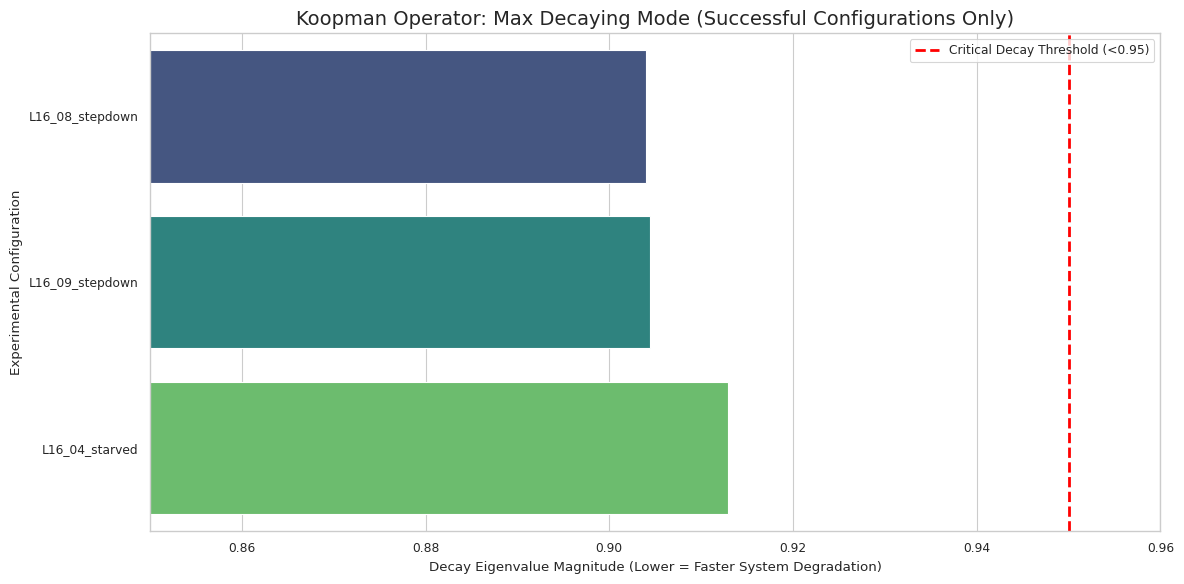

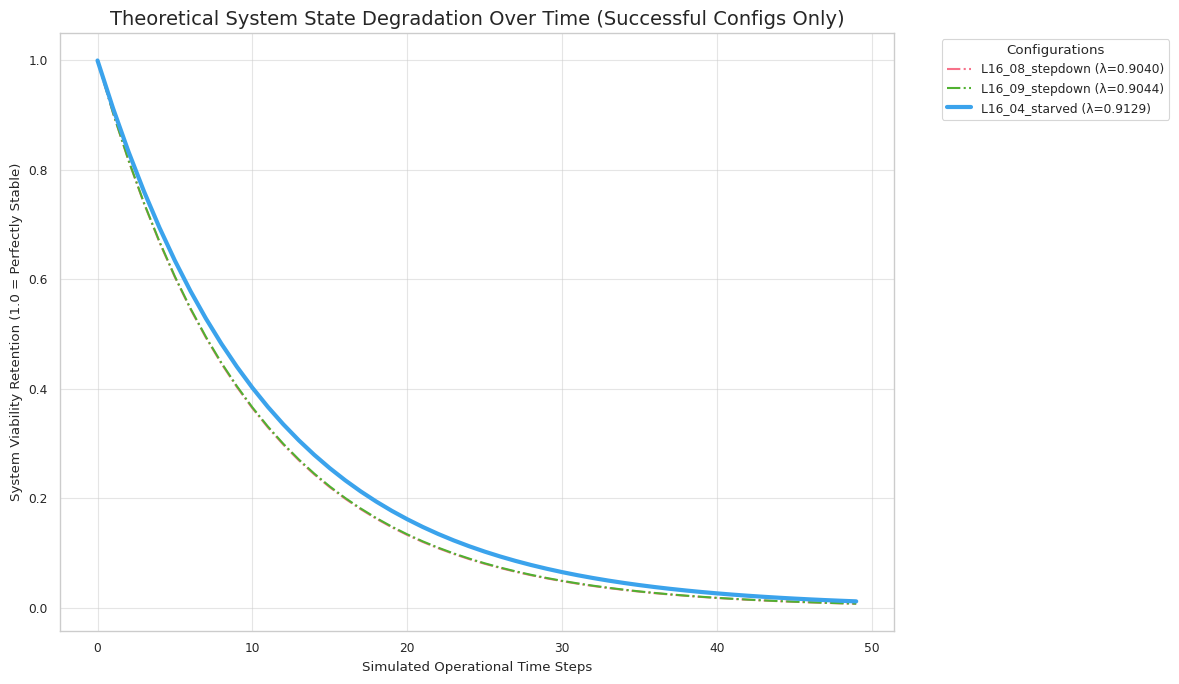

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Merge the Koopman matrix with your newly calculated Success/Failure table
df_master = pd.merge(df_koopman_summary, final_table, on='Run Config', how='inner')

# 2. Filter for ONLY the fully successful runs (where all jobs completed)
df_successful = df_master[df_master['Successes'] == df_master['Total']].copy()

print(f"Filtered dataset down to {len(df_successful)} fully successful configurations.")

# Set the style for academic plotting
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14})

# ==========================================
# GRAPH 1: Decaying Mode Comparison (Bar Chart)
# ==========================================
plt.figure(figsize=(12, 6))

# Sort by decay mode so the worst degrading systems are at the top/bottom
df_sorted = df_successful.sort_values('Decaying Mode (|lambda_decay|)', ascending=True)

# Create a bar plot
ax = sns.barplot(
    data=df_sorted,
    x='Decaying Mode (|lambda_decay|)',
    y='Run Config',
    palette='viridis'
)

# Add a vertical red line to show the "Critical Decay Threshold"
plt.axvline(x=0.95, color='red', linestyle='--', linewidth=2, label='Critical Decay Threshold (<0.95)')

plt.title("Koopman Operator: Max Decaying Mode (Successful Configurations Only)")
plt.xlabel("Decay Eigenvalue Magnitude (Lower = Faster System Degradation)")
plt.ylabel("Experimental Configuration")
plt.xlim(0.85, 0.96) # Zoom in on the variance
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# GRAPH 2: Theoretical Decay Trajectories
# ==========================================
plt.figure(figsize=(12, 7))

# Simulate 50 time steps of system operation
t_steps = np.arange(0, 50)

# Define custom colors/markers to separate the configs visually
colors = sns.color_palette("husl", len(df_sorted))

for idx, (original_index, row) in enumerate(df_sorted.iterrows()):
    run_name = row['Run Config']
    lam = row['Decaying Mode (|lambda_decay|)']

    # Calculate the theoretical Koopman trajectory: x(t) = lambda^t
    trajectory = np.power(lam, t_steps)

    # Emphasize the 'Starved' configs vs 'Baseline'
    if 'starved' in run_name.lower():
        line_style = '-'
        line_width = 3
    elif 'baseline' in run_name.lower():
        line_style = '--'
        line_width = 2
    else:
        line_style = '-.'
        line_width = 1.5

    plt.plot(t_steps, trajectory, label=f"{run_name} (λ={lam:.4f})",
             linestyle=line_style, linewidth=line_width, color=colors[idx])

plt.title("Theoretical System State Degradation Over Time (Successful Configs Only)")
plt.xlabel("Simulated Operational Time Steps")
plt.ylabel("System Viability Retention (1.0 = Perfectly Stable)")

# Add a grid and a legend outside the plot
plt.grid(True, alpha=0.5)
plt.legend(title="Configurations", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### ### Generate Koopman Operator decay charts (failures only)

Filtered dataset down to 11 failed configurations.


/tmp/ipykernel_2238/1590997759.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


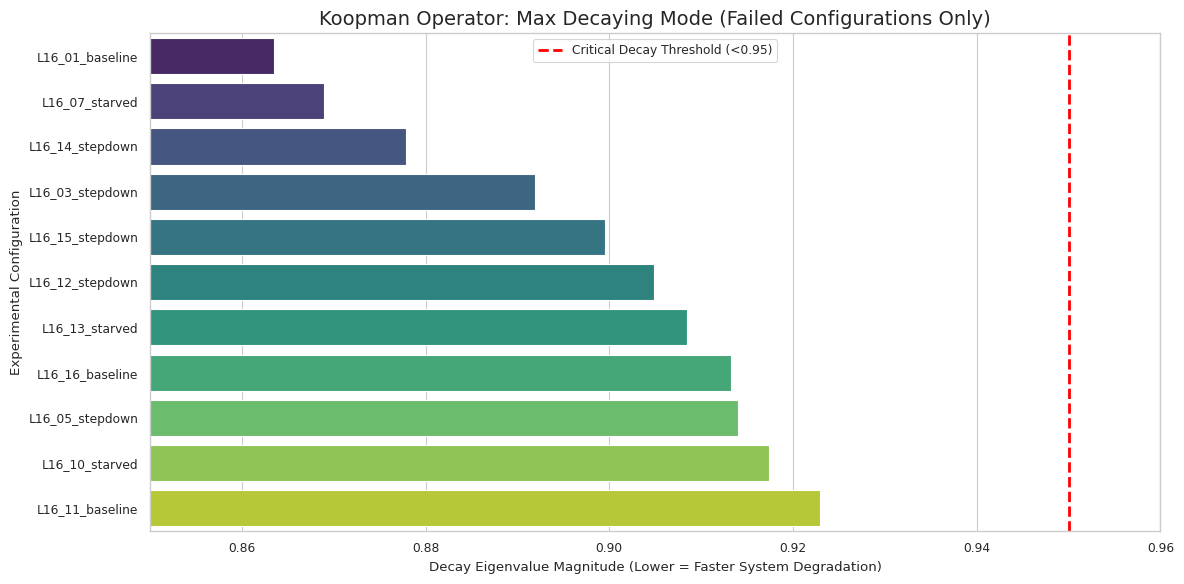

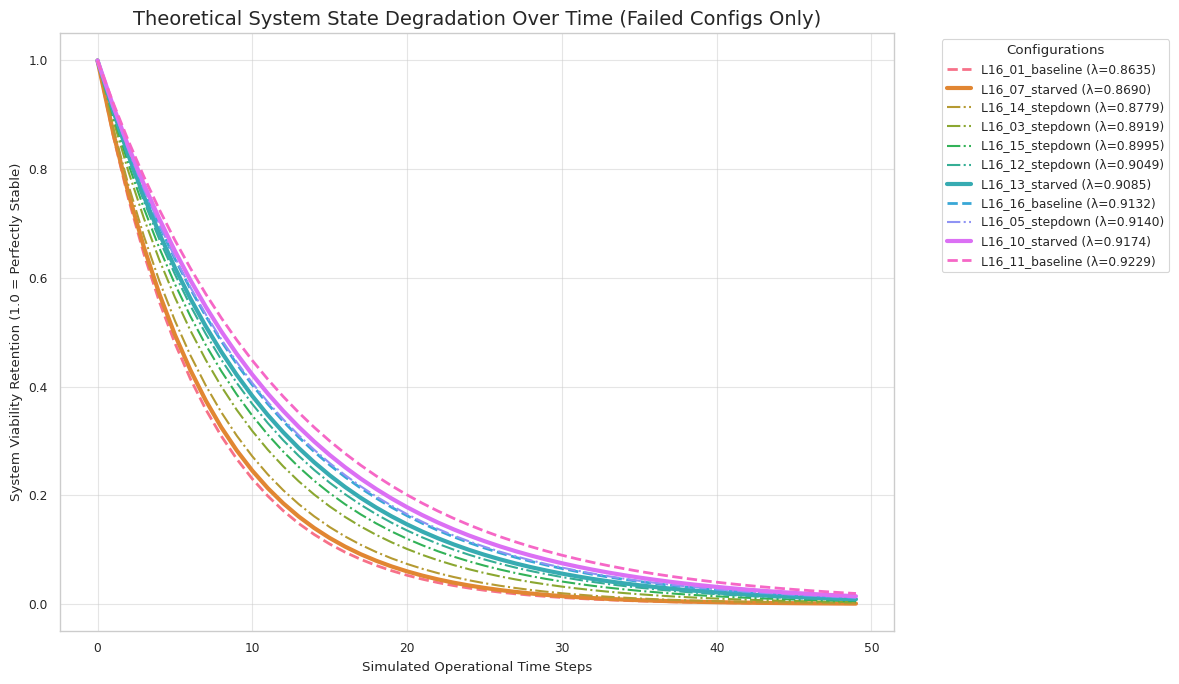

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Merge the Koopman matrix with your newly calculated Success/Failure table
# (Assuming df_master is still in memory; re-merging just to be safe)
df_master = pd.merge(df_koopman_summary, final_table, on='Run Config', how='inner')

# 2. Filter for ONLY the runs that experienced at least one failure
df_failed = df_master[df_master['Failures'] > 0].copy()

print(f"Filtered dataset down to {len(df_failed)} failed configurations.")

# Set the style for academic plotting
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14})

# ==========================================
# GRAPH 1: Decaying Mode Comparison (Bar Chart)
# ==========================================
plt.figure(figsize=(12, 6))

# Sort by decay mode so the worst degrading systems are at the top/bottom
df_sorted = df_failed.sort_values('Decaying Mode (|lambda_decay|)', ascending=True)

# Create a bar plot
ax = sns.barplot(
    data=df_sorted,
    x='Decaying Mode (|lambda_decay|)',
    y='Run Config',
    palette='viridis'
)

# Add a vertical red line to show the "Critical Decay Threshold"
plt.axvline(x=0.95, color='red', linestyle='--', linewidth=2, label='Critical Decay Threshold (<0.95)')

plt.title("Koopman Operator: Max Decaying Mode (Failed Configurations Only)")
plt.xlabel("Decay Eigenvalue Magnitude (Lower = Faster System Degradation)")
plt.ylabel("Experimental Configuration")
plt.xlim(0.85, 0.96) # Zoom in on the variance
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# GRAPH 2: Theoretical Decay Trajectories
# ==========================================
plt.figure(figsize=(12, 7))

# Simulate 50 time steps of system operation
t_steps = np.arange(0, 50)

# Define custom colors/markers to separate the configs visually
colors = sns.color_palette("husl", len(df_sorted))

for idx, (original_index, row) in enumerate(df_sorted.iterrows()):
    run_name = row['Run Config']
    lam = row['Decaying Mode (|lambda_decay|)']

    # Calculate the theoretical Koopman trajectory: x(t) = lambda^t
    trajectory = np.power(lam, t_steps)

    # Emphasize the 'Starved' configs vs 'Baseline'
    if 'starved' in run_name.lower():
        line_style = '-'
        line_width = 3
    elif 'baseline' in run_name.lower():
        line_style = '--'
        line_width = 2
    else:
        line_style = '-.'
        line_width = 1.5

    plt.plot(t_steps, trajectory, label=f"{run_name} (λ={lam:.4f})",
             linestyle=line_style, linewidth=line_width, color=colors[idx])

plt.title("Theoretical System State Degradation Over Time (Failed Configs Only)")
plt.xlabel("Simulated Operational Time Steps")
plt.ylabel("System Viability Retention (1.0 = Perfectly Stable)")

# Add a grid and a legend outside the plot
plt.grid(True, alpha=0.5)
plt.legend(title="Configurations", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Generate non-key charts

### Generate jobs completion chart (test for restarts)

<>:149: SyntaxWarning: invalid escape sequence '\('
<>:149: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_2238/3641777545.py:149: SyntaxWarning: invalid escape sequence '\('
  plt.show()


Setting safety limits and mapping disk swap...
Extracting job completions directly from Gold anomalies master...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Extraction complete! Reduced dataset to 72 clean step points. Rendering plot...


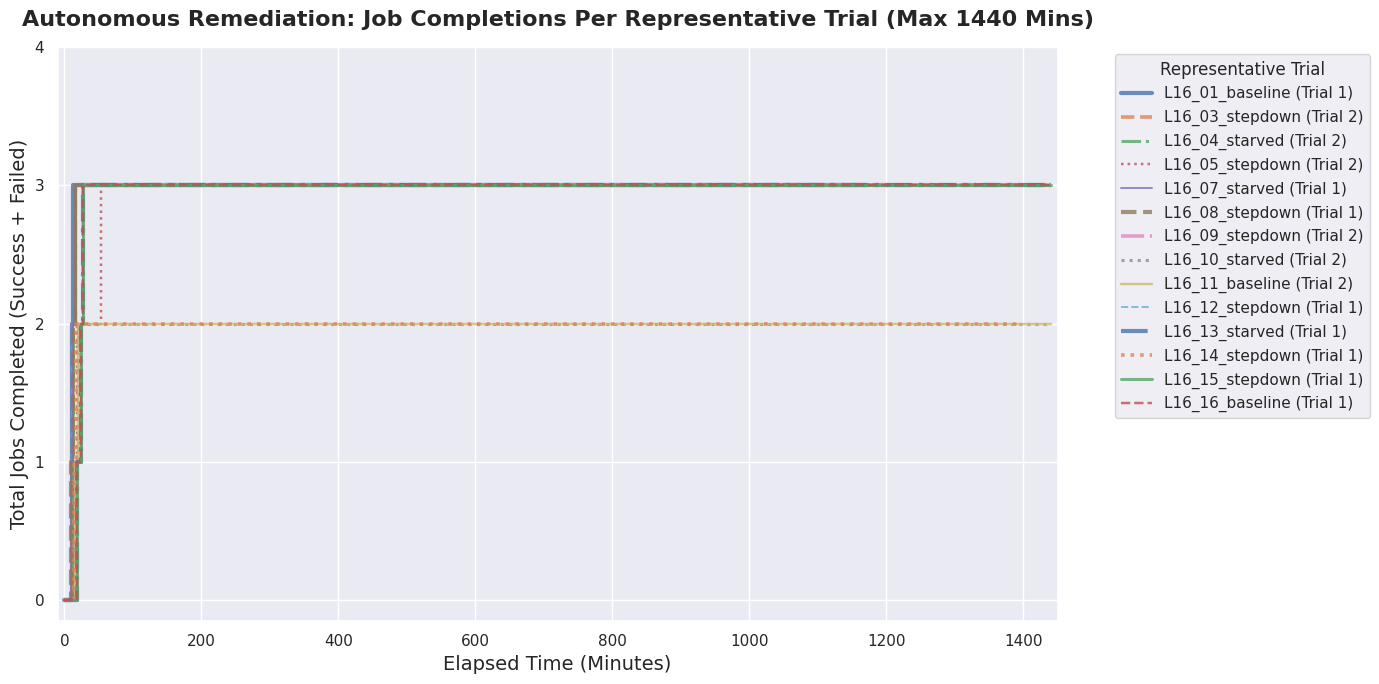

In [35]:
import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

con = duckdb.connect()

# 1. Apply DuckDB Safety Pragmas
print("Setting safety limits and mapping disk swap...")
con.execute("SET preserve_insertion_order = false;")
con.execute("PRAGMA memory_limit='6GB'")
con.execute("PRAGMA temp_directory='/content/duckdb_swap'")

gold_lakehouse_path = '/content/lakehouse_archive/gold/anomalies_master.parquet'

print("Extracting job completions directly from Gold anomalies master...")

# 2. Vectorized Gold Extraction + Sessionization + Representative Filter
duckdb_plot_query = f"""
WITH base_gold AS (
    SELECT
        run_name,
        timestamp,
        message
    FROM read_parquet('{gold_lakehouse_path}')
    WHERE message LIKE '%Jobs complete%'
),
-- Detect physical execution gaps (>30 mins) to identify distinct trial attempts
session_gaps AS (
    SELECT
        run_name,
        timestamp,
        message,
        CASE
            WHEN EPOCH(timestamp) - EPOCH(LAG(timestamp) OVER (PARTITION BY run_name ORDER BY timestamp ASC)) > 1800
            THEN 1 ELSE 0
        END AS is_new_trial
    FROM base_gold
),
-- Assign trial numbers (Trial 1, Trial 2, etc.) per run_name
trial_indexed AS (
    SELECT
        run_name,
        timestamp,
        message,
        SUM(is_new_trial) OVER (PARTITION BY run_name ORDER BY timestamp ASC ROWS UNBOUNDED PRECEDING) + 1 AS trial_num
    FROM session_gaps
),
-- Calculate elapsed time per individual trial attempt
trial_timeline AS (
    SELECT
        run_name || ' (Trial ' || trial_num || ')' AS trial_id,
        run_name,
        timestamp,
        (EPOCH(timestamp) - EPOCH(MIN(timestamp) OVER (PARTITION BY run_name, trial_num))) / 60.0 AS elapsed_minutes,
        TRY_CAST(regexp_extract(message, 'Jobs complete \((\d+) success', 1) AS INT) +
        TRY_CAST(regexp_extract(message, '(\d+) failed\)', 1) AS INT) AS raw_jobs
    FROM trial_indexed
),
-- Enforce the 1440-minute (24-hour) hard cap and compute cumulative max
bounded_timeline AS (
    SELECT
        trial_id,
        run_name,
        LEAST(elapsed_minutes, 1440.0) AS elapsed_minutes,
        MAX(raw_jobs) OVER (
            PARTITION BY trial_id
            ORDER BY elapsed_minutes ASC
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS cumulative_jobs
    FROM trial_timeline
    WHERE elapsed_minutes <= 1440.0  -- Hard 24-hour cap
),
-- Calculate trial summaries separately to avoid nested window functions
trial_summaries AS (
    SELECT
        trial_id,
        run_name,
        MAX(cumulative_jobs) AS max_jobs,
        MAX(elapsed_minutes) AS max_time
    FROM bounded_timeline
    GROUP BY trial_id, run_name
),
-- Rank and select the single best trial per configuration
best_trials AS (
    SELECT trial_id
    FROM trial_summaries
    QUALIFY ROW_NUMBER() OVER (
        PARTITION BY run_name
        ORDER BY max_jobs DESC, max_time DESC
    ) = 1
),
-- Downsample: Keep start points, step-up events, and final 1440m end points
downsampled_steps AS (
    SELECT
        trial_id,
        run_name,
        elapsed_minutes,
        cumulative_jobs,
        LAG(cumulative_jobs) OVER (PARTITION BY trial_id ORDER BY elapsed_minutes ASC) AS prev_jobs,
        LEAD(cumulative_jobs) OVER (PARTITION BY trial_id ORDER BY elapsed_minutes ASC) AS next_jobs
    FROM bounded_timeline
    WHERE trial_id IN (SELECT trial_id FROM best_trials)
)
SELECT
    trial_id,
    run_name,
    elapsed_minutes,
    cumulative_jobs
FROM downsampled_steps
WHERE prev_jobs IS NULL              -- Trial Start
   OR next_jobs IS NULL              -- Trial End
   OR cumulative_jobs != prev_jobs   -- Step Change
ORDER BY run_name ASC, elapsed_minutes ASC;
"""

df_plot = con.execute(duckdb_plot_query).df()

print(f"Extraction complete! Reduced dataset to {len(df_plot)} clean step points. Rendering plot...")

# 3. Clean Plotting (Bounded to 0 - 1440 Minutes)
plt.figure(figsize=(14, 7))
line_styles = ['-', '--', '-.', ':']

for i, trial in enumerate(df_plot['trial_id'].unique()):
    trial_data = df_plot[df_plot['trial_id'] == trial]
    current_width = max(1.0, 3.0 - ((i % 5) * 0.4))

    plt.plot(trial_data['elapsed_minutes'], trial_data['cumulative_jobs'],
             drawstyle='steps-post',
             linewidth=current_width,
             alpha=0.8,
             linestyle=line_styles[i % 4],
             label=trial)

plt.title('Autonomous Remediation: Job Completions Per Representative Trial (Max 1440 Mins)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Elapsed Time (Minutes)', fontsize=14)
plt.ylabel('Total Jobs Completed (Success + Failed)', fontsize=14)

plt.xlim(-10, 1450)  # Locked strictly to the 24-hour operational window
if not df_plot.empty:
    plt.yticks(range(0, int(df_plot['cumulative_jobs'].max(skipna=True)) + 2))
plt.legend(title='Representative Trial', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Generate workers connected chart

Setting safety limits and mapping disk swap...
Extracting worker connection timelines directly from Gold master...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Extraction complete! Reduced dataset to 108 step points across 14 base runs. Rendering plot...


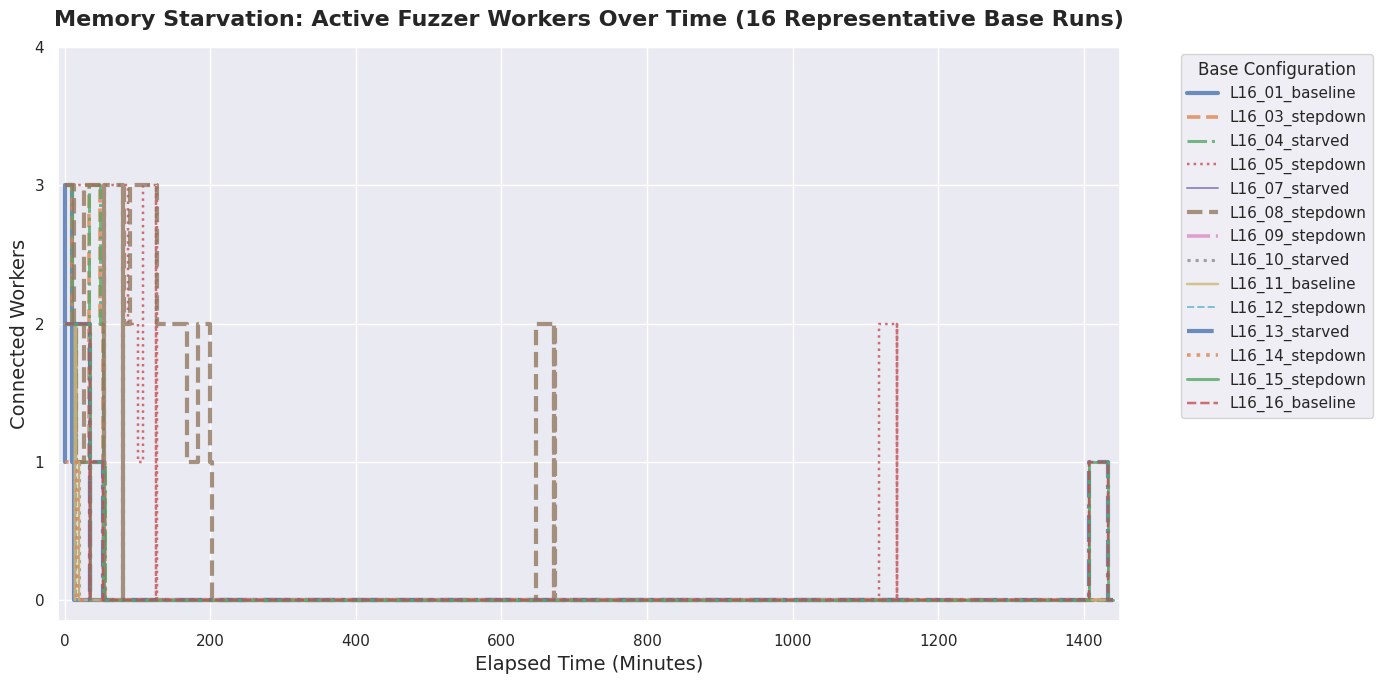

In [36]:
import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

con = duckdb.connect()

# 1. Apply DuckDB Safety Pragmas
print("Setting safety limits and mapping disk swap...")
con.execute("SET preserve_insertion_order = false;")
con.execute("PRAGMA memory_limit='6GB'")
con.execute("PRAGMA temp_directory='/content/duckdb_swap'")

gold_lakehouse_path = '/content/lakehouse_archive/gold/anomalies_master.parquet'

print("Extracting worker connection timelines directly from Gold master...")

# 2. Vectorized Gold Extraction + Representative Trial Selection + Downsampling
# Note: Double backslashes (\\s, \\d) prevent Python SyntaxWarnings
duckdb_worker_query = f"""
WITH base_gold AS (
    SELECT
        run_name,
        timestamp,
        message
    FROM read_parquet('{gold_lakehouse_path}')
    WHERE message LIKE '%Workers connected%'
),
-- Detect physical execution gaps (>30 mins) to identify distinct trial attempts
session_gaps AS (
    SELECT
        run_name,
        timestamp,
        message,
        CASE
            WHEN EPOCH(timestamp) - EPOCH(LAG(timestamp) OVER (PARTITION BY run_name ORDER BY timestamp ASC)) > 1800
            THEN 1 ELSE 0
        END AS is_new_trial
    FROM base_gold
),
-- Assign trial numbers per run_name
trial_indexed AS (
    SELECT
        run_name,
        timestamp,
        message,
        SUM(is_new_trial) OVER (PARTITION BY run_name ORDER BY timestamp ASC ROWS UNBOUNDED PRECEDING) + 1 AS trial_num
    FROM session_gaps
),
-- Calculate elapsed time per trial attempt and extract active worker count
trial_timeline AS (
    SELECT
        run_name || ' (Trial ' || trial_num || ')' AS trial_id,
        run_name,
        timestamp,
        (EPOCH(timestamp) - EPOCH(MIN(timestamp) OVER (PARTITION BY run_name, trial_num))) / 60.0 AS elapsed_minutes,
        TRY_CAST(regexp_extract(message, 'Workers connected:\\s*(\\d+)', 1) AS INT) AS active_workers
    FROM trial_indexed
),
-- Enforce the 1440-minute (24-hour) hard cap
bounded_timeline AS (
    SELECT
        trial_id,
        run_name,
        LEAST(elapsed_minutes, 1440.0) AS elapsed_minutes,
        active_workers
    FROM trial_timeline
    WHERE elapsed_minutes <= 1440.0  -- Hard 24-hour cap
),
-- Calculate trial summaries to select the single best representative trial per base run
trial_summaries AS (
    SELECT
        trial_id,
        run_name,
        MAX(active_workers) AS max_workers,
        MAX(elapsed_minutes) AS max_time
    FROM bounded_timeline
    GROUP BY trial_id, run_name
),
-- Filter down to exactly 1 representative trial per base configuration
best_trials AS (
    SELECT trial_id
    FROM trial_summaries
    QUALIFY ROW_NUMBER() OVER (
        PARTITION BY run_name
        ORDER BY max_time DESC, max_workers DESC
    ) = 1
),
-- Downsample: Keep start points, worker count changes, and end points
downsampled_steps AS (
    SELECT
        run_name,
        elapsed_minutes,
        active_workers,
        LAG(active_workers) OVER (PARTITION BY run_name ORDER BY elapsed_minutes ASC) AS prev_workers,
        LEAD(active_workers) OVER (PARTITION BY run_name ORDER BY elapsed_minutes ASC) AS next_workers
    FROM bounded_timeline
    WHERE trial_id IN (SELECT trial_id FROM best_trials)
)
SELECT
    run_name,
    elapsed_minutes,
    active_workers
FROM downsampled_steps
WHERE prev_workers IS NULL              -- Trial Start
   OR next_workers IS NULL              -- Trial End
   OR active_workers != prev_workers    -- Worker Count Change (Spin-up or OOM Kill)
ORDER BY run_name ASC, elapsed_minutes ASC;
"""

df_plot = con.execute(duckdb_worker_query).df()

print(f"Extraction complete! Reduced dataset to {len(df_plot)} step points across {df_plot['run_name'].nunique()} base runs. Rendering plot...")

# 3. Clean Diagnostic Plot (Original 16 Base Configurations)
plt.figure(figsize=(14, 7))
line_styles = ['-', '--', '-.', ':']

for i, run_name in enumerate(df_plot['run_name'].unique()):
    run_data = df_plot[df_plot['run_name'] == run_name]
    current_width = max(1.0, 3.0 - ((i % 5) * 0.4))

    plt.plot(run_data['elapsed_minutes'], run_data['active_workers'],
             drawstyle='steps-post',
             linewidth=current_width,
             alpha=0.8,
             linestyle=line_styles[i % 4],
             label=run_name)

plt.title('Memory Starvation: Active Fuzzer Workers Over Time (16 Representative Base Runs)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Elapsed Time (Minutes)', fontsize=14)
plt.ylabel('Connected Workers', fontsize=14)

plt.xlim(-10, 1450)  # Bounded strictly to 24 hours
if not df_plot.empty:
    plt.yticks(range(0, int(df_plot['active_workers'].max(skipna=True)) + 2))

plt.legend(title='Base Configuration', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Scatterplot/Correlation matrix

Setting safety limits and mapping disk swap...
Extracting hardware correlations across all trial attempts directly from Gold master...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Extraction complete! Summarized 25 distinct trial attempts. Rendering scatterplots...


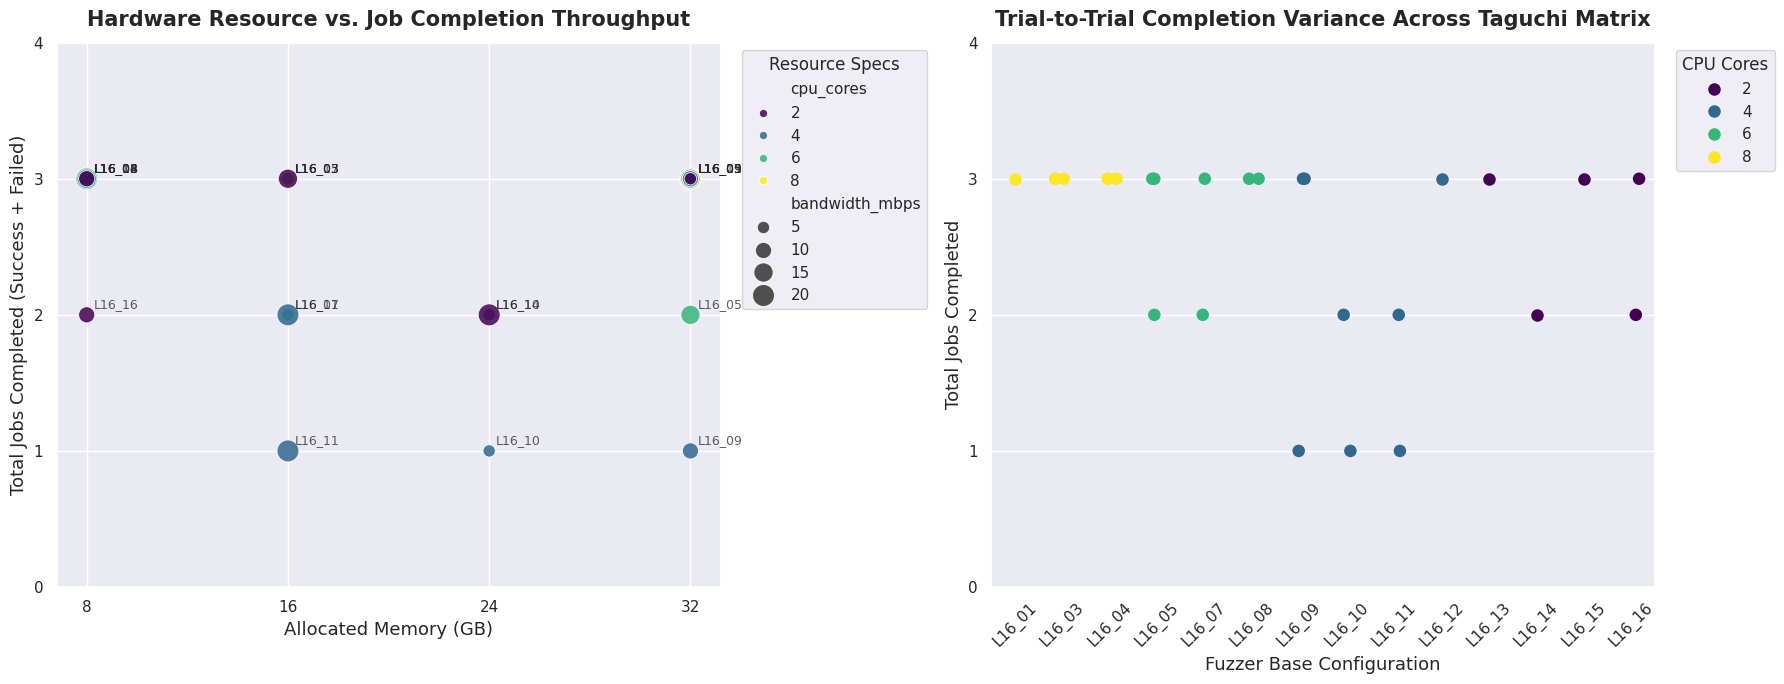

In [37]:
import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

con = duckdb.connect()

# 1. Apply DuckDB Safety Pragmas
print("Setting safety limits and mapping disk swap...")
con.execute("SET preserve_insertion_order = false;")
con.execute("PRAGMA memory_limit='6GB'")
con.execute("PRAGMA temp_directory='/content/duckdb_swap'")

gold_lakehouse_path = '/content/lakehouse_archive/gold/anomalies_master.parquet'

print("Extracting hardware correlations across all trial attempts directly from Gold master...")

# 2. Vectorized Gold Extraction + L16 Taguchi Mapping + Base Config Normalization
duckdb_scatter_query = f"""
WITH l16_matrix AS (
    SELECT * FROM (VALUES
        ('L16_01', 8, 32, 20),
        ('L16_02', 8, 24, 15),
        ('L16_03', 8, 16, 10),
        ('L16_04', 8,  8,  5),
        ('L16_05', 6, 32, 15),
        ('L16_06', 6, 24, 10),
        ('L16_07', 6, 16,  5),
        ('L16_08', 6,  8, 20),
        ('L16_09', 4, 32, 10),
        ('L16_10', 4, 24,  5),
        ('L16_11', 4, 16, 20),
        ('L16_12', 4,  8, 15),
        ('L16_13', 2, 32,  5),
        ('L16_14', 2, 24, 20),
        ('L16_15', 2, 16, 15),
        ('L16_16', 2,  8, 10)
    ) AS t(base_config, cpu_cores, memory_gb, bandwidth_mbps)
),
base_gold AS (
    SELECT
        -- Extract the normalized base configuration ID (e.g., L16_01)
        UPPER(regexp_extract(run_name, '(?i)(L16_\\d{{2}})', 1)) AS base_config,
        run_name AS raw_run_name,
        timestamp,
        message
    FROM read_parquet('{gold_lakehouse_path}')
    WHERE message LIKE '%Jobs complete%'
),
session_gaps AS (
    SELECT
        base_config,
        raw_run_name,
        timestamp,
        message,
        CASE
            WHEN EPOCH(timestamp) - EPOCH(LAG(timestamp) OVER (PARTITION BY raw_run_name ORDER BY timestamp ASC)) > 1800
            THEN 1 ELSE 0
        END AS is_new_trial
    FROM base_gold
),
trial_indexed AS (
    SELECT
        base_config,
        raw_run_name,
        timestamp,
        message,
        SUM(is_new_trial) OVER (PARTITION BY raw_run_name ORDER BY timestamp ASC ROWS UNBOUNDED PRECEDING) + 1 AS trial_num
    FROM session_gaps
),
trial_timeline AS (
    SELECT
        raw_run_name || ' (T' || trial_num || ')' AS trial_id,
        base_config,
        raw_run_name,
        trial_num,
        (EPOCH(timestamp) - EPOCH(MIN(timestamp) OVER (PARTITION BY raw_run_name, trial_num))) / 60.0 AS elapsed_minutes,
        TRY_CAST(regexp_extract(message, 'Jobs complete \\((\\d+) success', 1) AS INT) +
        TRY_CAST(regexp_extract(message, '(\\d+) failed\\)', 1) AS INT) AS raw_jobs
    FROM trial_indexed
),
bounded_timeline AS (
    SELECT
        trial_id,
        base_config,
        raw_run_name,
        trial_num,
        LEAST(elapsed_minutes, 1440.0) AS elapsed_minutes,
        raw_jobs
    FROM trial_timeline
    WHERE elapsed_minutes <= 1440.0
),
trial_summaries AS (
    SELECT
        trial_id,
        base_config,
        raw_run_name,
        trial_num,
        MAX(raw_jobs) AS total_jobs_completed,
        MAX(elapsed_minutes) AS total_duration_mins
    FROM bounded_timeline
    GROUP BY trial_id, base_config, raw_run_name, trial_num
)
SELECT
    s.trial_id,
    s.base_config,
    s.raw_run_name,
    s.trial_num,
    m.cpu_cores,
    m.memory_gb,
    m.bandwidth_mbps,
    s.total_jobs_completed,
    s.total_duration_mins
FROM trial_summaries s
JOIN l16_matrix m ON s.base_config = m.base_config
ORDER BY m.cpu_cores DESC, m.memory_gb DESC, s.trial_num ASC;
"""

df_scatter = con.execute(duckdb_scatter_query).df()

print(f"Extraction complete! Summarized {len(df_scatter)} distinct trial attempts. Rendering scatterplots...")

# 3. PLOTTING: MULTI-PANEL CORRELATION ANALYSIS
if df_scatter.empty:
    print("Error: No matching trial records found. Check base_config extraction regex.")
else:
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 7))

    # --- PANEL 1: Memory vs. Jobs Completed (Hue = CPU Cores, Size = Bandwidth) ---
    sns.scatterplot(
        data=df_scatter,
        x='memory_gb',
        y='total_jobs_completed',
        hue='cpu_cores',
        size='bandwidth_mbps',
        sizes=(80, 250),
        palette='viridis',
        alpha=0.85,
        ax=ax1
    )

    ax1.set_title('Hardware Resource vs. Job Completion Throughput', fontsize=15, fontweight='bold', pad=12)
    ax1.set_xlabel('Allocated Memory (GB)', fontsize=13)
    ax1.set_ylabel('Total Jobs Completed (Success + Failed)', fontsize=13)
    ax1.set_xticks([8, 16, 24, 32])

    max_jobs = df_scatter['total_jobs_completed'].max(skipna=True)
    if pd.notna(max_jobs):
        ax1.set_yticks(range(0, int(max_jobs) + 2))

    for _, row in df_scatter.iterrows():
        ax1.annotate(
            row['base_config'],
            (row['memory_gb'], row['total_jobs_completed']),
            xytext=(5, 5), textcoords='offset points', fontsize=9, alpha=0.75
        )

    ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Resource Specs')

    # --- PANEL 2: Distribution Across All Executed Trial Attempts ---
    sns.stripplot(
        data=df_scatter,
        x='base_config',
        y='total_jobs_completed',
        hue='cpu_cores',
        palette='viridis',
        size=9,
        jitter=0.2,
        dodge=False,
        ax=ax2
    )

    ax2.set_title('Trial-to-Trial Completion Variance Across Taguchi Matrix', fontsize=15, fontweight='bold', pad=12)
    ax2.set_xlabel('Fuzzer Base Configuration', fontsize=13)
    ax2.set_ylabel('Total Jobs Completed', fontsize=13)
    ax2.tick_params(axis='x', rotation=45)

    if pd.notna(max_jobs):
        ax2.set_yticks(range(0, int(max_jobs) + 2))

    ax2.legend(title='CPU Cores', bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

### Correlation between jobs and runners

Setting safety limits and mapping disk swap...
Extracting representative job completions and worker timelines directly from Gold master...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Extraction complete! Reduced timeline data across 14 representative base runs. Rendering subplots...


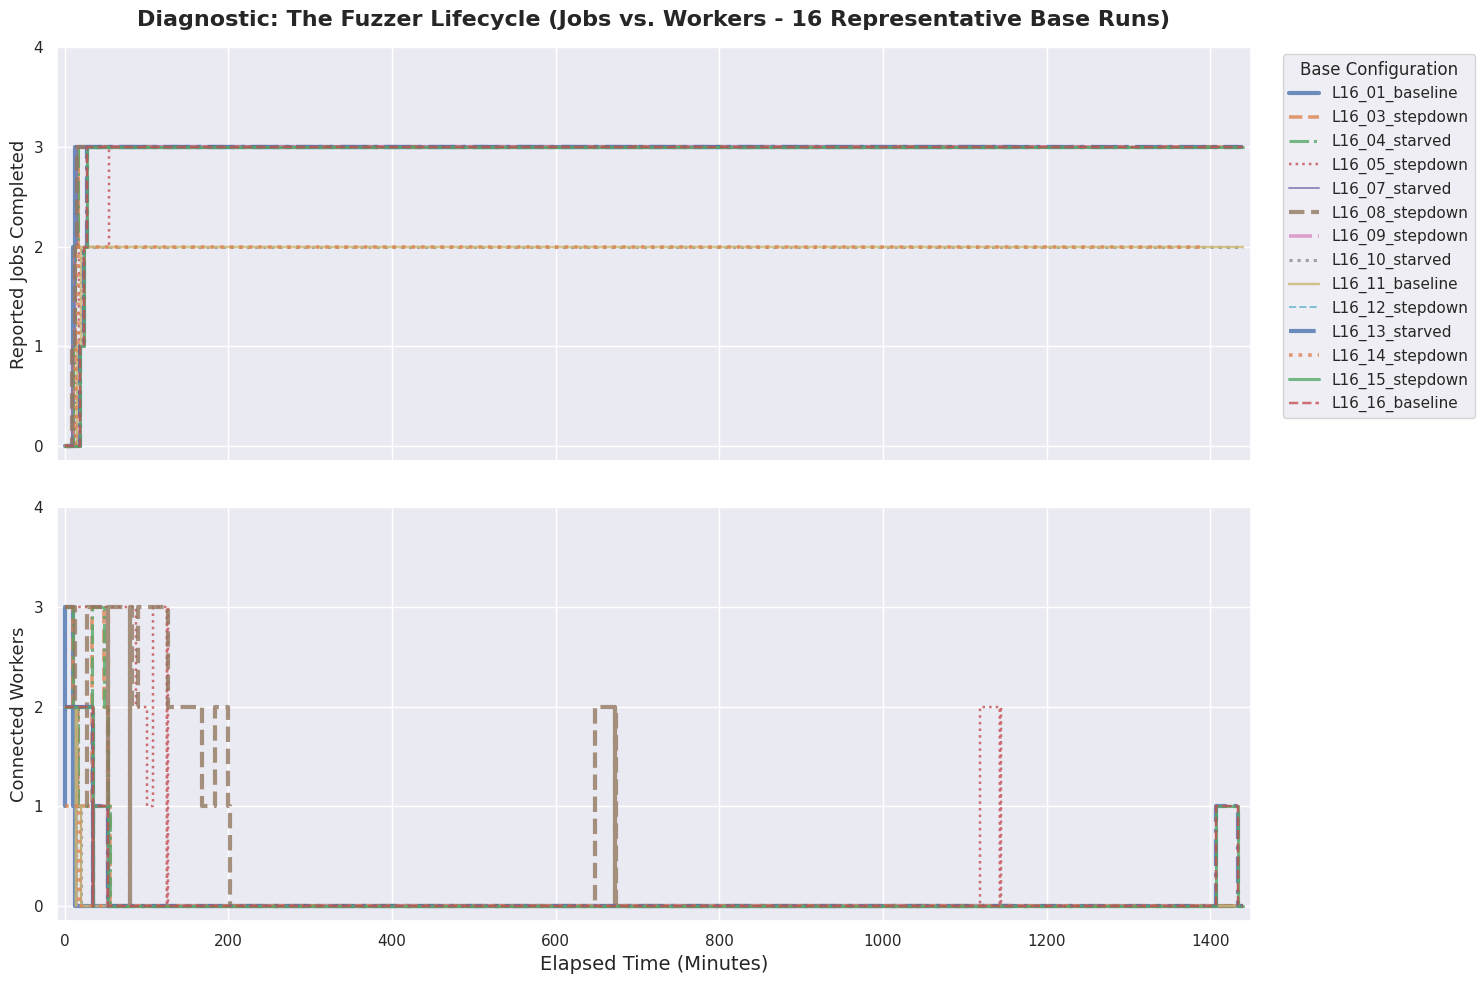

In [38]:
import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

con = duckdb.connect()

# 1. Apply DuckDB Safety Pragmas
print("Setting safety limits and mapping disk swap...")
con.execute("SET preserve_insertion_order = false;")
con.execute("PRAGMA memory_limit='6GB'")
con.execute("PRAGMA temp_directory='/content/duckdb_swap'")

gold_lakehouse_path = '/content/lakehouse_archive/gold/anomalies_master.parquet'

print("Extracting representative job completions and worker timelines directly from Gold master...")

# 2. Vectorized Gold Extraction: Jobs Completed Timeline
# Note: Double backslashes (\\d, \\() prevent Python SyntaxWarnings inside f-strings
duckdb_jobs_query = f"""
WITH base_gold AS (
    SELECT
        run_name,
        timestamp,
        message
    FROM read_parquet('{gold_lakehouse_path}')
    WHERE message LIKE '%Jobs complete%'
),
session_gaps AS (
    SELECT
        run_name,
        timestamp,
        message,
        CASE
            WHEN EPOCH(timestamp) - EPOCH(LAG(timestamp) OVER (PARTITION BY run_name ORDER BY timestamp ASC)) > 1800
            THEN 1 ELSE 0
        END AS is_new_trial
    FROM base_gold
),
trial_indexed AS (
    SELECT
        run_name,
        timestamp,
        message,
        SUM(is_new_trial) OVER (PARTITION BY run_name ORDER BY timestamp ASC ROWS UNBOUNDED PRECEDING) + 1 AS trial_num
    FROM session_gaps
),
trial_timeline AS (
    SELECT
        run_name || ' (Trial ' || trial_num || ')' AS trial_id,
        run_name,
        timestamp,
        (EPOCH(timestamp) - EPOCH(MIN(timestamp) OVER (PARTITION BY run_name, trial_num))) / 60.0 AS elapsed_minutes,
        TRY_CAST(regexp_extract(message, 'Jobs complete \\((\\d+) success', 1) AS INT) +
        TRY_CAST(regexp_extract(message, '(\\d+) failed\\)', 1) AS INT) AS raw_jobs
    FROM trial_indexed
),
bounded_timeline AS (
    SELECT
        trial_id,
        run_name,
        LEAST(elapsed_minutes, 1440.0) AS elapsed_minutes,
        MAX(raw_jobs) OVER (
            PARTITION BY trial_id
            ORDER BY elapsed_minutes ASC
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS cumulative_jobs
    FROM trial_timeline
    WHERE elapsed_minutes <= 1440.0
),
trial_summaries AS (
    SELECT
        trial_id,
        run_name,
        MAX(cumulative_jobs) AS max_jobs,
        MAX(elapsed_minutes) AS max_time
    FROM bounded_timeline
    GROUP BY trial_id, run_name
),
best_trials AS (
    SELECT trial_id
    FROM trial_summaries
    QUALIFY ROW_NUMBER() OVER (
        PARTITION BY run_name
        ORDER BY max_jobs DESC, max_time DESC
    ) = 1
),
downsampled_steps AS (
    SELECT
        run_name,
        elapsed_minutes,
        cumulative_jobs,
        LAG(cumulative_jobs) OVER (PARTITION BY run_name ORDER BY elapsed_minutes ASC) AS prev_jobs,
        LEAD(cumulative_jobs) OVER (PARTITION BY run_name ORDER BY elapsed_minutes ASC) AS next_jobs
    FROM bounded_timeline
    WHERE trial_id IN (SELECT trial_id FROM best_trials)
)
SELECT
    run_name,
    elapsed_minutes,
    cumulative_jobs AS jobs
FROM downsampled_steps
WHERE prev_jobs IS NULL
   OR next_jobs IS NULL
   OR cumulative_jobs != prev_jobs
ORDER BY run_name ASC, elapsed_minutes ASC;
"""

# 3. Vectorized Gold Extraction: Active Workers Timeline
duckdb_workers_query = f"""
WITH base_gold AS (
    SELECT
        run_name,
        timestamp,
        message
    FROM read_parquet('{gold_lakehouse_path}')
    WHERE message LIKE '%Workers connected%'
),
session_gaps AS (
    SELECT
        run_name,
        timestamp,
        message,
        CASE
            WHEN EPOCH(timestamp) - EPOCH(LAG(timestamp) OVER (PARTITION BY run_name ORDER BY timestamp ASC)) > 1800
            THEN 1 ELSE 0
        END AS is_new_trial
    FROM base_gold
),
trial_indexed AS (
    SELECT
        run_name,
        timestamp,
        message,
        SUM(is_new_trial) OVER (PARTITION BY run_name ORDER BY timestamp ASC ROWS UNBOUNDED PRECEDING) + 1 AS trial_num
    FROM session_gaps
),
trial_timeline AS (
    SELECT
        run_name || ' (Trial ' || trial_num || ')' AS trial_id,
        run_name,
        timestamp,
        (EPOCH(timestamp) - EPOCH(MIN(timestamp) OVER (PARTITION BY run_name, trial_num))) / 60.0 AS elapsed_minutes,
        TRY_CAST(regexp_extract(message, 'Workers connected:\\s*(\\d+)', 1) AS INT) AS active_workers
    FROM trial_indexed
),
bounded_timeline AS (
    SELECT
        trial_id,
        run_name,
        LEAST(elapsed_minutes, 1440.0) AS elapsed_minutes,
        active_workers
    FROM trial_timeline
    WHERE elapsed_minutes <= 1440.0
),
trial_summaries AS (
    SELECT
        trial_id,
        run_name,
        MAX(active_workers) AS max_workers,
        MAX(elapsed_minutes) AS max_time
    FROM bounded_timeline
    GROUP BY trial_id, run_name
),
best_trials AS (
    SELECT trial_id
    FROM trial_summaries
    QUALIFY ROW_NUMBER() OVER (
        PARTITION BY run_name
        ORDER BY max_time DESC, max_workers DESC
    ) = 1
),
downsampled_steps AS (
    SELECT
        run_name,
        elapsed_minutes,
        active_workers,
        LAG(active_workers) OVER (PARTITION BY run_name ORDER BY elapsed_minutes ASC) AS prev_workers,
        LEAD(active_workers) OVER (PARTITION BY run_name ORDER BY elapsed_minutes ASC) AS next_workers
    FROM bounded_timeline
    WHERE trial_id IN (SELECT trial_id FROM best_trials)
)
SELECT
    run_name,
    elapsed_minutes,
    active_workers
FROM downsampled_steps
WHERE prev_workers IS NULL
   OR next_workers IS NULL
   OR active_workers != prev_workers
ORDER BY run_name ASC, elapsed_minutes ASC;
"""

df_jobs = con.execute(duckdb_jobs_query).df()
df_workers = con.execute(duckdb_workers_query).df()

print(f"Extraction complete! Reduced timeline data across {df_jobs['run_name'].nunique()} representative base runs. Rendering subplots...")

# 4. PLOTTING: DUAL-AXIS SUBPLOTS
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(15, 10), sharex=True)

line_styles = ['-', '--', '-.', ':']
all_runs = sorted(list(set(df_jobs['run_name'].unique()).union(set(df_workers['run_name'].unique()))))

for i, run in enumerate(all_runs):
    current_style = line_styles[i % 4]
    current_width = max(1.0, 3.0 - ((i % 5) * 0.4))

    # Plot Top Graph (Jobs)
    run_jobs = df_jobs[df_jobs['run_name'] == run]
    if not run_jobs.empty:
        ax1.plot(run_jobs['elapsed_minutes'], run_jobs['jobs'],
                 drawstyle='steps-post', linewidth=current_width,
                 alpha=0.8, linestyle=current_style, label=run)

    # Plot Bottom Graph (Workers)
    run_workers = df_workers[df_workers['run_name'] == run]
    if not run_workers.empty:
        ax2.plot(run_workers['elapsed_minutes'], run_workers['active_workers'],
                 drawstyle='steps-post', linewidth=current_width,
                 alpha=0.8, linestyle=current_style, label=run)

# Format Top Subplot (Jobs)
ax1.set_title('Diagnostic: The Fuzzer Lifecycle (Jobs vs. Workers - 16 Representative Base Runs)', fontsize=16, fontweight='bold', pad=15)
ax1.set_ylabel('Reported Jobs Completed', fontsize=13)
if not df_jobs.empty:
    ax1.set_yticks(range(0, int(df_jobs['jobs'].max(skipna=True)) + 2))

# Legend on top subplot only, positioned cleanly to the right
ax1.legend(title='Base Configuration', bbox_to_anchor=(1.02, 1), loc='upper left')

# Format Bottom Subplot (Workers)
ax2.set_xlabel('Elapsed Time (Minutes)', fontsize=14)
ax2.set_ylabel('Connected Workers', fontsize=13)
ax2.set_xlim(-10, 1450)  # Bounded strictly to 24 hours
if not df_workers.empty:
    ax2.set_yticks(range(0, int(df_workers['active_workers'].max(skipna=True)) + 2))

plt.tight_layout()
plt.show()